## Anomaly Clustering - STDBSCAN
* Prepare and launch multiexecution and storing results in memory.
    * Different parameters.
    * Record execution time.

#### Imports

In [5]:
from ocean_tools.io.readers import get_xarray_from_file
from ocean_tools.config.defaults import REGIONS
from ocean_tools.processing.data_prep import prepare_dataset_for_analysis
from ocean_tools.processing.clustering import segment_anomalies, segment_n_variable_anomalies, label_connected_components_dbscan
from ocean_tools.visualization.maps import plot_n_spatial_variable
from ocean_tools.io.writers import store_pickle_variable

import warnings
warnings.filterwarnings('ignore')

# Configuración inicial
REGION = REGIONS['cclme']
DATASETS = {
    'sst': "./data/exports/patched_ds/AQUA_MODIS_MONTHLY.2002-08-01_2025-01-01.nc",
    'chlor_a': "./data/exports/patched_ds/AQUA_MODIS_MONTHLY_CHLOR.2002-08-01_2025-01-01.nc"
}

exports_path = './data/exports/clusters/mv_experiments/'

In [2]:
ds_sst_raw = get_xarray_from_file(DATASETS['sst']).sel(
    time=slice('2002-08-01', '2025-01-01'), 
    lat=slice(REGION['lat'][1], REGION ['lat'][0]),
    lon=slice(REGION['lon'][0], REGION ['lon'][1])
)

ds_sst_chlor = get_xarray_from_file(DATASETS['chlor_a']).sel(
    time=slice('2002-08-01', '2025-01-01'), 
    lat=slice(REGION['lat'][1], REGION ['lat'][0]),
    lon=slice(REGION['lon'][0], REGION ['lon'][1])
)

ds_sst_anom_neg_full = prepare_dataset_for_analysis(ds_sst_raw.copy(), 'sst', use_anomalies=True, anomaly_transform='negative')
ds_chlor_anom_pos_full = prepare_dataset_for_analysis(ds_sst_chlor.copy(), 'chlor_a', use_anomalies=True, anomaly_transform='positive')

#### Single Experiment Testing

(array([3.4789159e+07, 5.2048800e+05, 2.4455800e+05, 1.4648100e+05,
        9.9126000e+04, 7.2134000e+04, 5.4929000e+04, 4.2760000e+04,
        3.3373000e+04, 2.7139000e+04, 2.2211000e+04, 1.8254000e+04,
        1.5395000e+04, 1.3134000e+04, 1.1062000e+04, 9.6230000e+03,
        8.3580000e+03, 7.3000000e+03, 6.3690000e+03, 5.7250000e+03,
        4.9430000e+03, 4.3070000e+03, 3.7730000e+03, 3.3330000e+03,
        2.9640000e+03, 2.6670000e+03, 2.3250000e+03, 2.0480000e+03,
        1.8850000e+03, 1.6130000e+03, 1.4880000e+03, 1.2980000e+03,
        1.1550000e+03, 1.0370000e+03, 9.5200000e+02, 8.0400000e+02,
        8.2900000e+02, 7.5900000e+02, 6.7000000e+02, 6.4000000e+02,
        5.6500000e+02, 5.1800000e+02, 5.0500000e+02, 4.6800000e+02,
        4.4000000e+02, 4.1800000e+02, 4.0600000e+02, 3.6300000e+02,
        3.6300000e+02, 3.5200000e+02, 2.9600000e+02, 2.7700000e+02,
        2.7900000e+02, 2.4300000e+02, 2.6000000e+02, 2.2800000e+02,
        2.4600000e+02, 2.4600000e+02, 2.2000000e

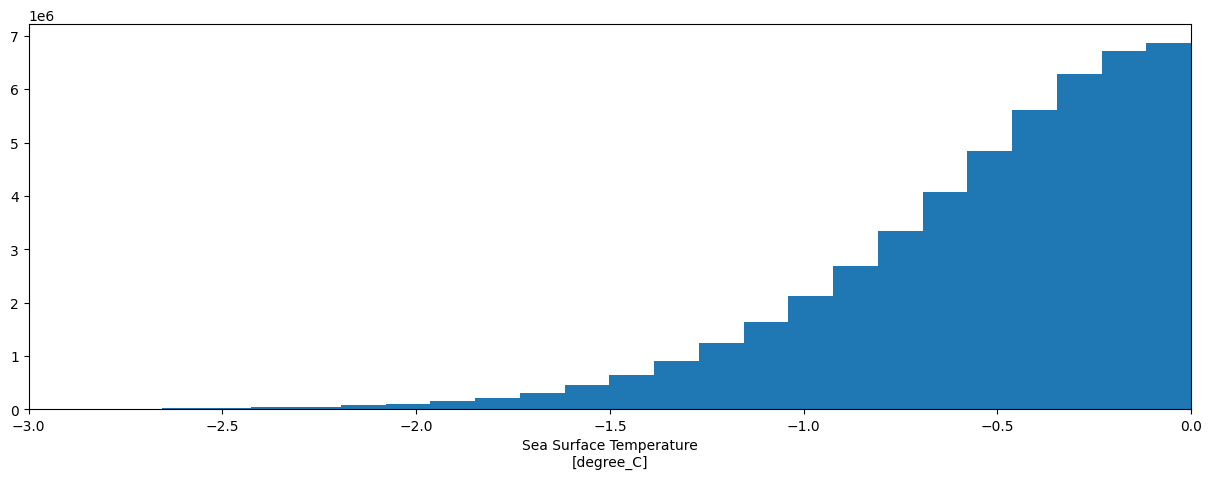

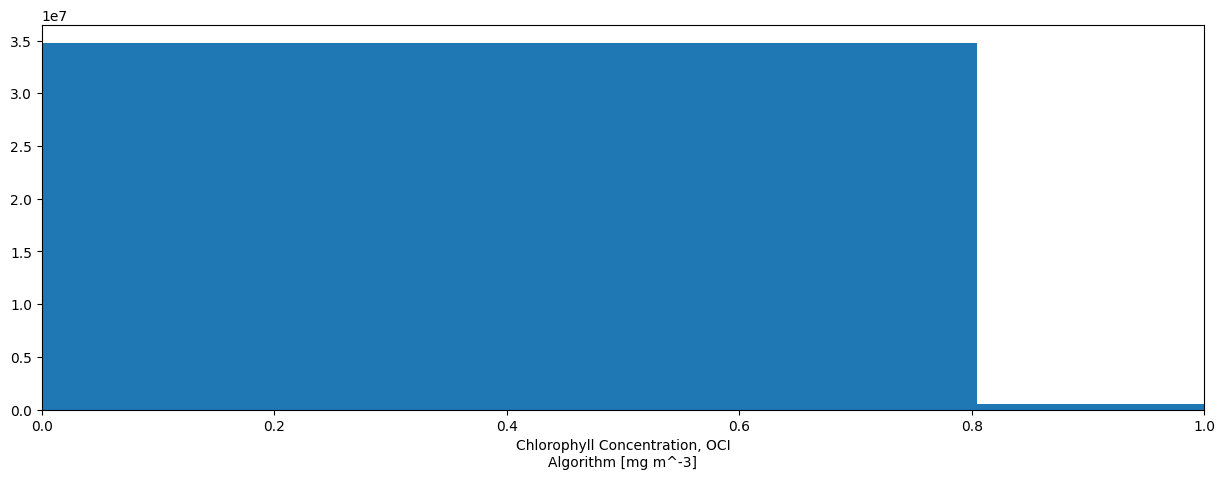

In [3]:
# Plot histogram of anomalies SST using matplotlib
ds_sst_anom_neg_full['sst'].plot.hist(bins=100, figsize=(15, 5), xlim=(-3, 0))

# Plot histogram of anomalies Chlorophyll using matplotlib
ds_chlor_anom_pos_full['chlor_a'].plot.hist(bins=100, figsize=(15, 5), xlim=(0, 1))

In [17]:
experiment =  [['sst', 'chlor_a'], '2018-01-01', '2018-12-01', [2, 5], 1, 10, 10, 500, 1, 'Basic Test']

variable_list, start_date, end_date, anomaly_threshold_list, eps_t, eps_lat, eps_lon, min_neighbors, min_cluster_size, experiment_name = experiment
store_dir=exports_path

file_name=f"clustering_experiment_{start_date}_{end_date}_{'-'.join(variable_list)}_{'-'.join(map(str, anomaly_threshold_list))}_{eps_t}_{eps_lat}_{eps_lon}_{min_neighbors}_{min_cluster_size}"

print(f"Running experiment: {experiment_name}")

ds_sst_anom_neg = ds_sst_anom_neg_full.copy().sel(
    time=slice(start_date, end_date)
)

ds_chlor_anom_pos = ds_chlor_anom_pos_full.copy().sel(
    time=slice(start_date, end_date)
)

ds_anom_list = [ds_sst_anom_neg, ds_chlor_anom_pos]

ds_segmented = segment_n_variable_anomalies(ds_anom_list, variable_list, anomaly_threshold_list, union_type='and')

Running experiment: Basic Test


(12, 840, 600)
(12, 840, 600)
(12, 840, 600)


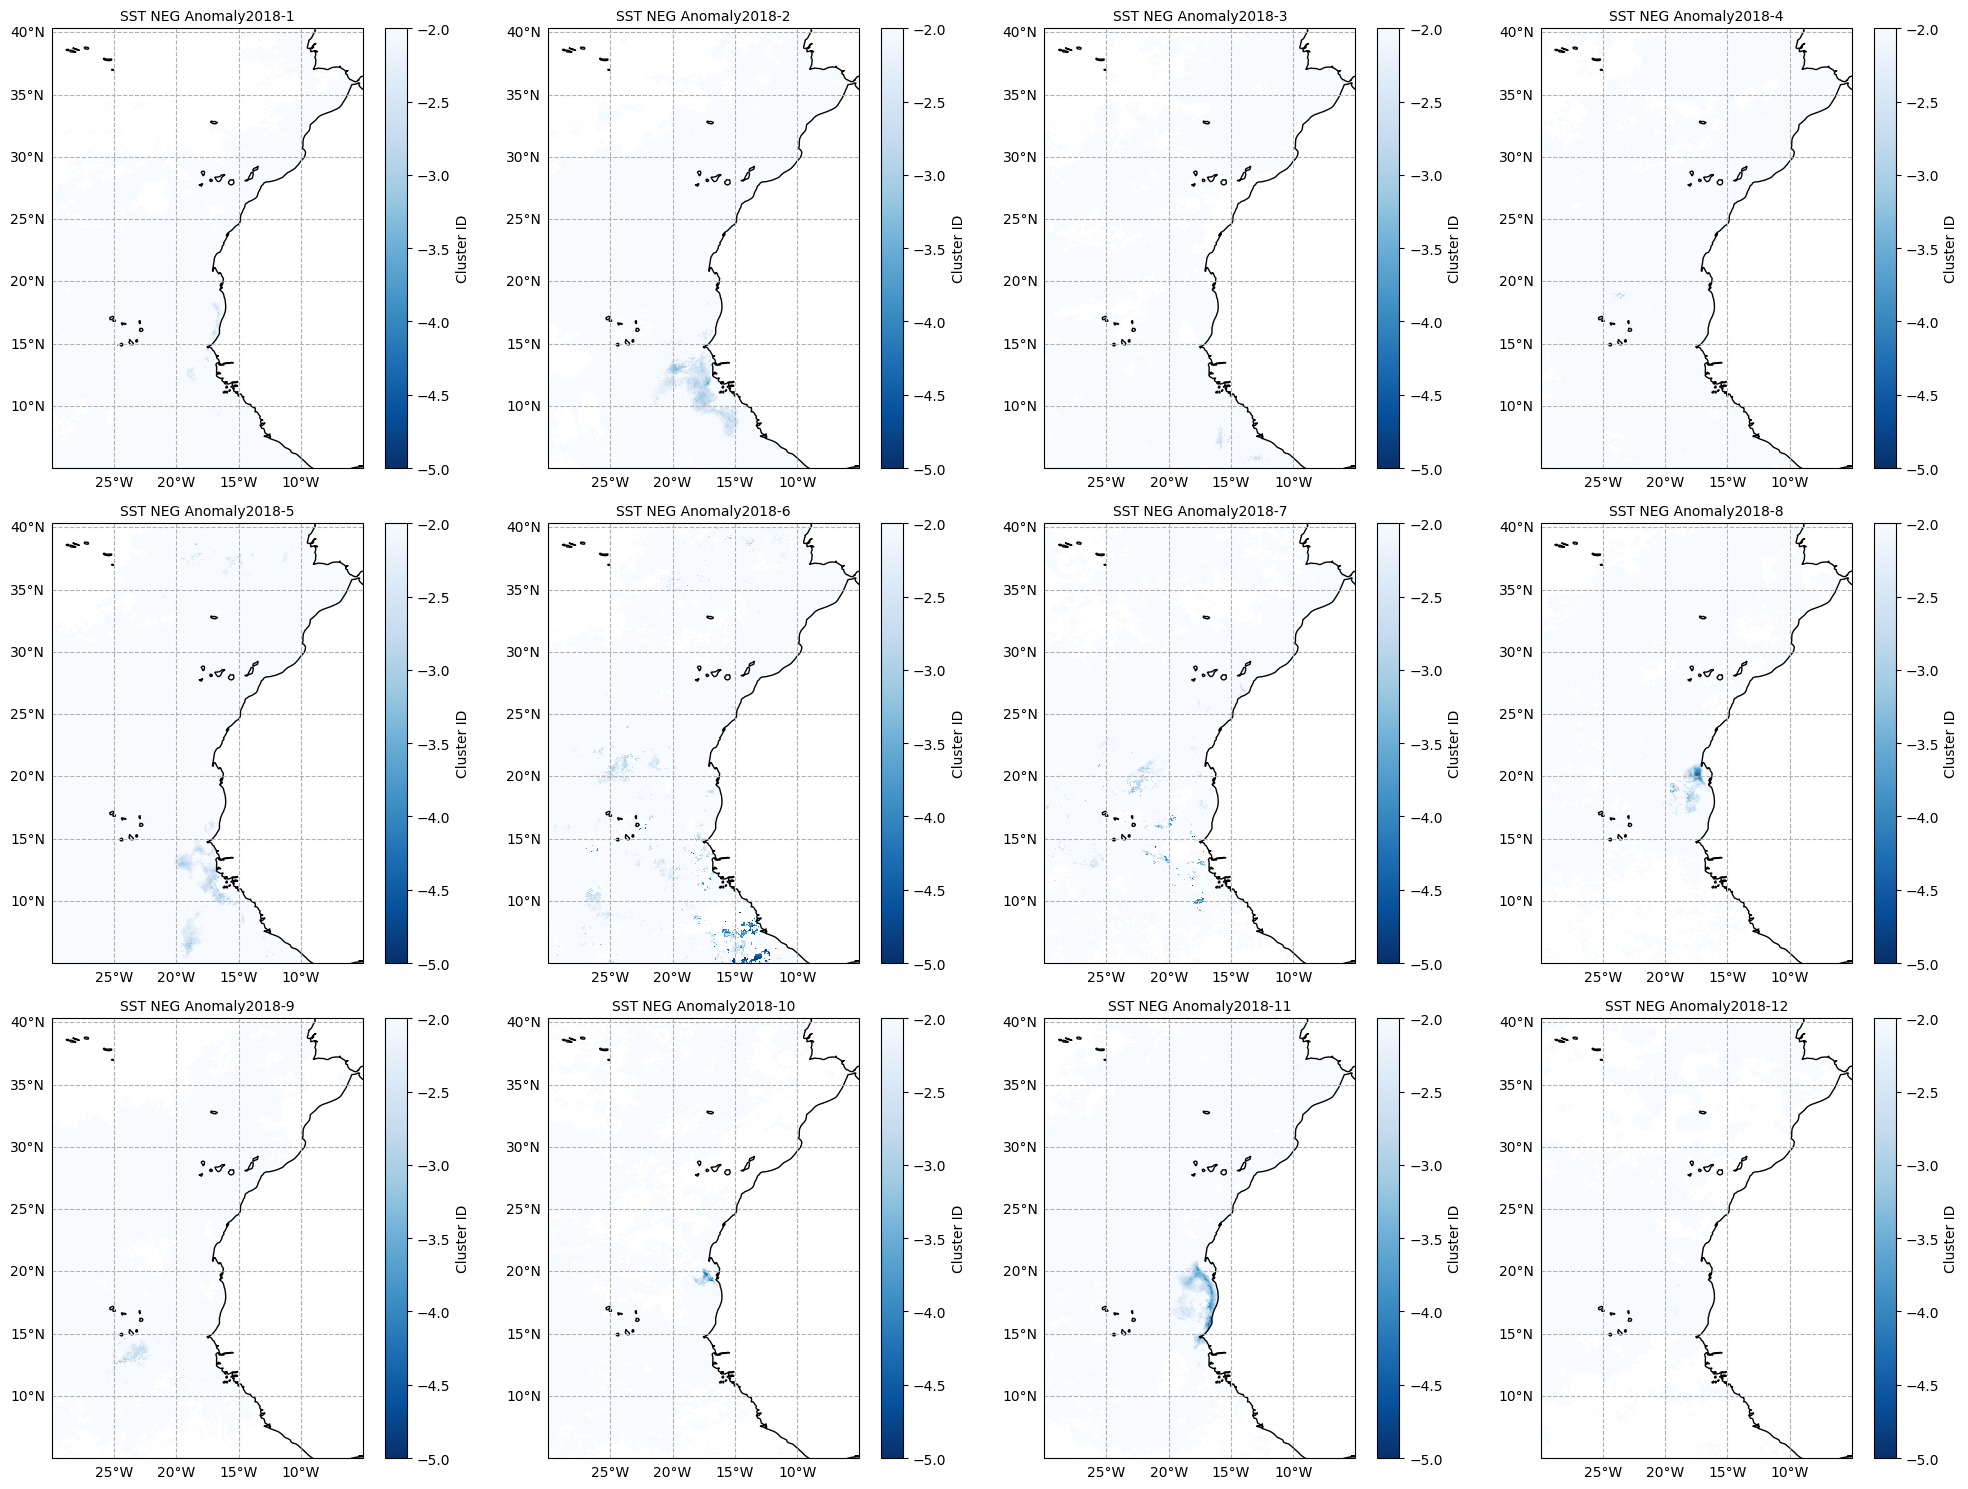

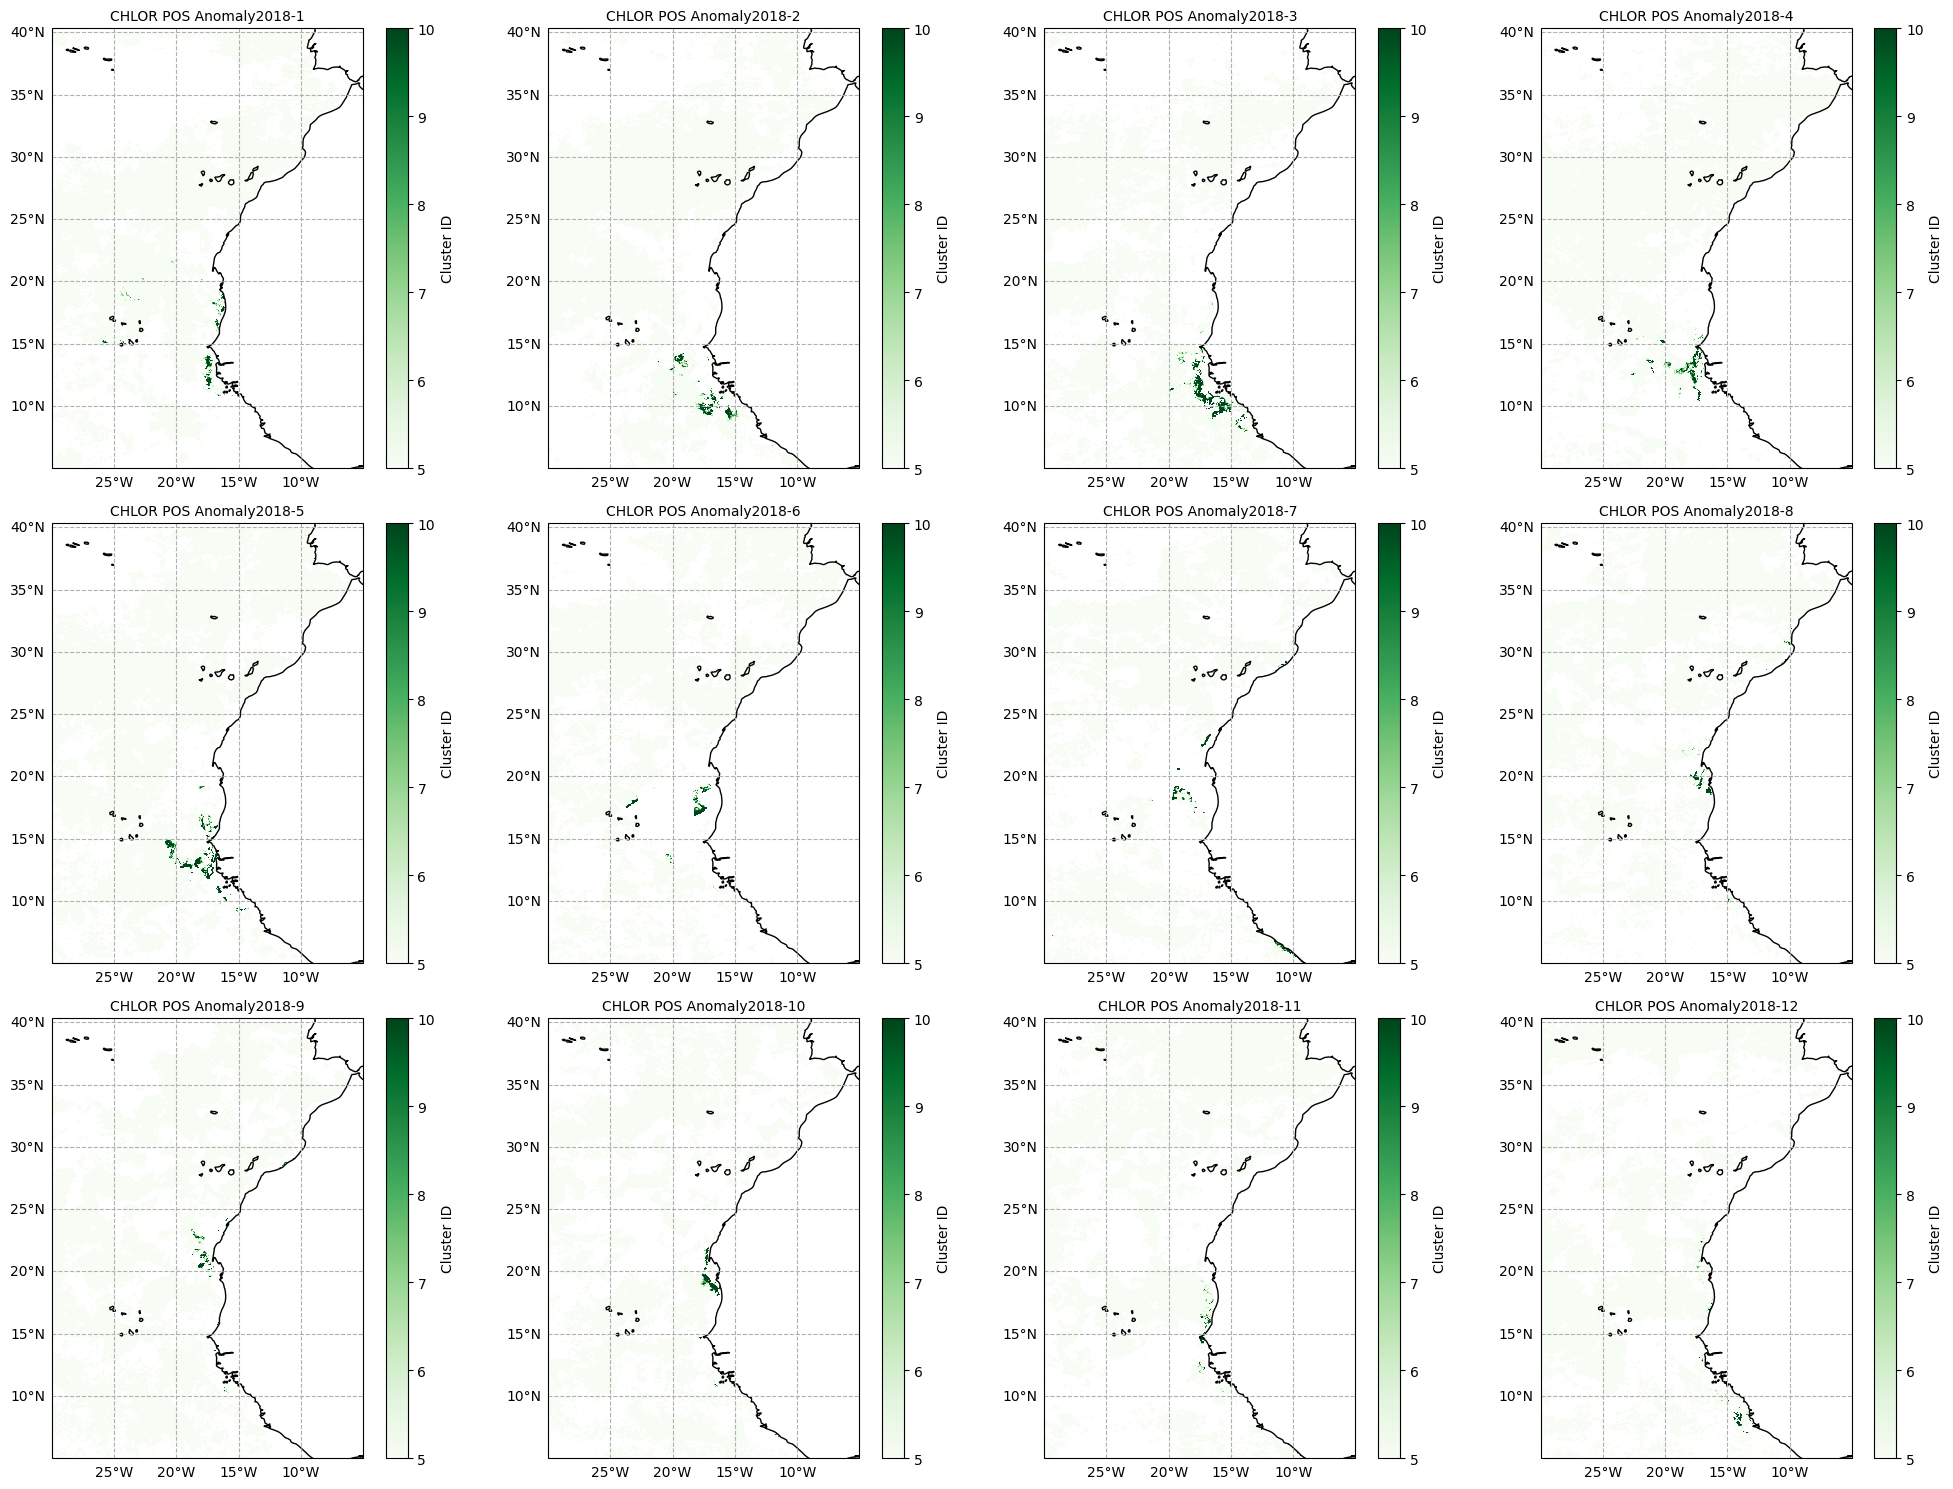

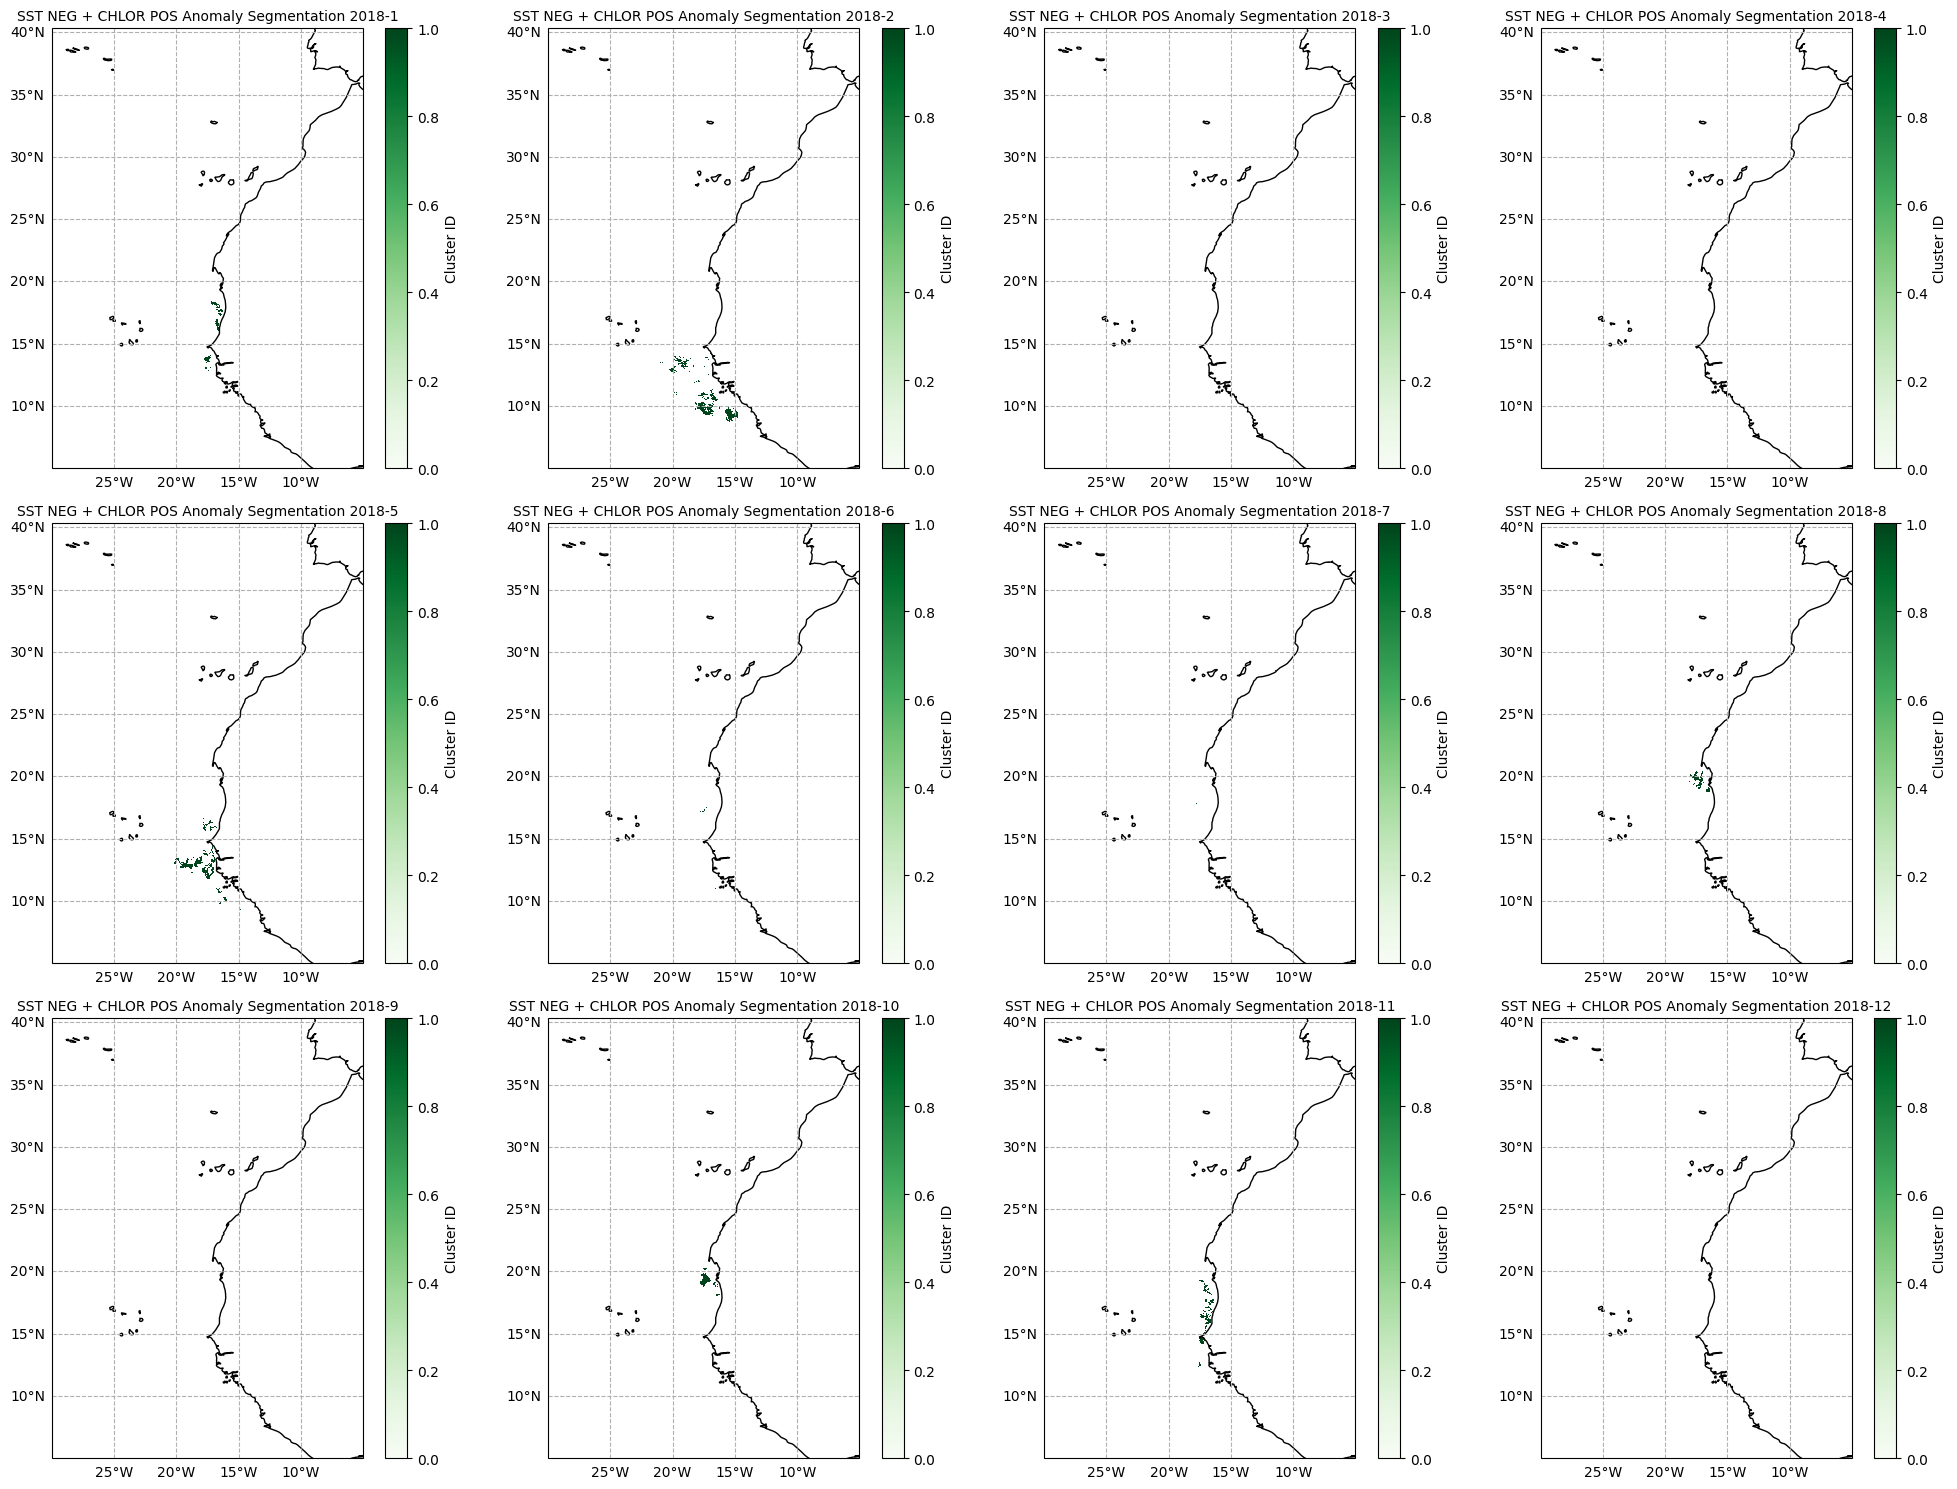

In [18]:
print(ds_sst_anom_neg['sst'].shape)
print(ds_chlor_anom_pos['chlor_a'].shape)
print(ds_segmented.shape)


plot_n_spatial_variable(
    [ds_sst_anom_neg['sst'][i] for i in range(12)],
    ds_sst_anom_neg.lat,
    ds_sst_anom_neg.lon,
    nrows = 3,
    ncols = 4,
    i_width = 5,
    i_height = 5,
    clim=[-5, -2], 
    titles = [f'SST NEG Anomaly{start_date[:4]}-{i+1}' for i in range(12)],
    plot_label = 'Cluster ID',
    cmap = 'Blues_r',
    norm_mode = 'none'
)

plot_n_spatial_variable(
    [ds_chlor_anom_pos['chlor_a'][i] for i in range(12)],
    ds_chlor_anom_pos.lat,
    ds_chlor_anom_pos.lon,
    nrows = 3,
    ncols = 4,
    i_width = 5,
    i_height = 5,
    clim=[5, 10], 
    titles = [f'CHLOR POS Anomaly{start_date[:4]}-{i+1}' for i in range(12)],
    plot_label = 'Cluster ID',
    cmap = 'Greens',
    norm_mode = 'none'
)

plot_n_spatial_variable(
    [ds_segmented[i] for i in range(12)],
    ds_sst_anom_neg.lat,
    ds_sst_anom_neg.lon,
    nrows = 3,
    ncols = 4,
    i_width = 5,
    i_height = 5,
    clim=[0, 1], 
    titles = [f'SST NEG + CHLOR POS Anomaly Segmentation {start_date[:4]}-{i+1}' for i in range(12)],
    plot_label = 'Cluster ID',
    cmap = 'Greens',
    norm_mode = 'none'
)

#### Experiment Set Definition

In [6]:
ExperimentSet = {
    'experiment_structure': ['variable_list', 'start_date', 'end_date', 'anomaly_threshold_list', 'eps_t', 'eps_lat', 'eps_lon', 'min_neighbors', 'min_cluster_size', 'experiment_name'],
    'experiments': [
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 40, 40, 300, 1, 'Base Full Period'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 40, 40, 100, 1, 'Smaller Min Neighbors'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 40, 40, 500, 1, 'Larger Min Neighbors'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 40, 40, 1000, 1, 'Much Larger Min Neighbors'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 20, 20, 300, 1, 'Smaller Geo Eps'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 60, 60, 300, 1, 'Larger Geo Eps'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 2, 40, 40, 300, 1, 'Larger Time Eps'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 12, 40, 40, 300, 1, 'Much Larger Time Eps'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 20, 20, 500, 1, '(2) Base Full Period'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 20, 20, 250, 1, '(2) Smaller Min Neighbors'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 20, 20, 750, 1, '(2) Larger Min Neighbors'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 20, 20, 1000, 1, '(2) Much Larger Min Neighbors'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 10, 10, 500, 1, '(2) Smaller Geo Eps'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 50, 50, 500, 1, '(2) Larger Geo Eps'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 2, 20, 20, 500, 1, '(2) Larger Time Eps'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 12, 20, 20, 500, 1, '(2) Much Larger Time Eps'],
    ]
}

#### Multi Experiment Execution

In [4]:
import time

exports_path = './data/exports/clusters/mv_experiments/'

for experiment in ExperimentSet['experiments']:

    variable_list, start_date, end_date, anomaly_threshold_list, eps_t, eps_lat, eps_lon, min_neighbors, min_cluster_size, experiment_name = experiment
    store_dir=exports_path

    file_name=f"clustering_experiment_{start_date}_{end_date}_{'-'.join(variable_list)}_{'-'.join(map(str, anomaly_threshold_list))}_{eps_t}_{eps_lat}_{eps_lon}_{min_neighbors}_{min_cluster_size}"

    print(f"Running experiment: {experiment_name}")

    ds_sst_anom_neg = ds_sst_anom_neg_full.copy().sel(
        time=slice(start_date, end_date)
    )

    ds_sst_chlor_pos = ds_chlor_anom_pos_full.copy().sel(
        time=slice(start_date, end_date)
    )

    ds_anom_list = [ds_sst_anom_neg, ds_sst_chlor_pos]

    ds_segmented = segment_n_variable_anomalies(ds_anom_list, variable_list, anomaly_threshold_list, union_type='and')

    start_time = time.time()
    clusters, n_clusters, n_discarded = label_connected_components_dbscan(ds_segmented, eps_t, eps_lat, eps_lon, min_neighbors, min_cluster_size)
    run_seconds = time.time() - start_time

    print(f"Found: {n_clusters} | Discarded: {n_discarded} | Runtime: {run_seconds:.2f} seconds")

    # Store
    store_pickle_variable(
        (clusters, n_clusters, n_discarded, run_seconds),
        store_dir,
        file_name
    )

Running experiment: (2) Base Full Period
Identified cluster #1 (2837)
Visited: 18.45%
Identified cluster #2 (8356)
Visited: 44.55%
Identified cluster #3 (1193)
Visited: 54.51%
Identified cluster #4 (2106)
Visited: 63.72%
Identified cluster #5 (1233)
Visited: 74.96%
Identified cluster #6 (910)
Visited: 81.87%
Found: 6 | Discarded: 0 | Runtime: 88.37 seconds
Running experiment: (2) Smaller Min Neighbors
Identified cluster #1 (1001)
Visited: 3.26%
Identified cluster #2 (376)
Visited: 6.40%
Identified cluster #3 (3358)
Visited: 18.48%
Identified cluster #4 (536)
Visited: 20.12%
Identified cluster #5 (638)
Visited: 22.85%
Identified cluster #6 (8611)
Visited: 44.60%
Identified cluster #7 (853)
Visited: 49.46%
Identified cluster #8 (537)
Visited: 51.25%
Identified cluster #9 (1303)
Visited: 54.51%
Identified cluster #10 (3417)
Visited: 65.95%
Identified cluster #11 (531)
Visited: 71.14%
Identified cluster #12 (2315)
Visited: 76.86%
Identified cluster #13 (2020)
Visited: 82.54%
Identified clu

#### Read Stored Results

In [7]:
# Read files if needed.
import pickle
import os

experiment_results = []
for experiment in ExperimentSet['experiments'][:8]:
    variable_list, start_date, end_date, anomaly_threshold_list, eps_t, eps_lat, eps_lon, min_neighbors, min_cluster_size, experiment_name = experiment
    file_name = f"clustering_experiment_{start_date}_{end_date}_{'-'.join(variable_list)}_{'-'.join(map(str, anomaly_threshold_list))}_{eps_t}_{eps_lat}_{eps_lon}_{min_neighbors}_{min_cluster_size}.pkl"
    clusters, n_clusters, n_discarded, run_seconds = pickle.load(open(os.path.join(exports_path, file_name), 'rb'))
    experiment_results.append((clusters, n_clusters, n_discarded, run_seconds, file_name, experiment_name))

#### Visualize Results

Experiment name: Base Full Period
Found: 15 | Discarded: 0 | Runtime: 334.91 seconds
File name: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_1_40_40_300_1.pkl


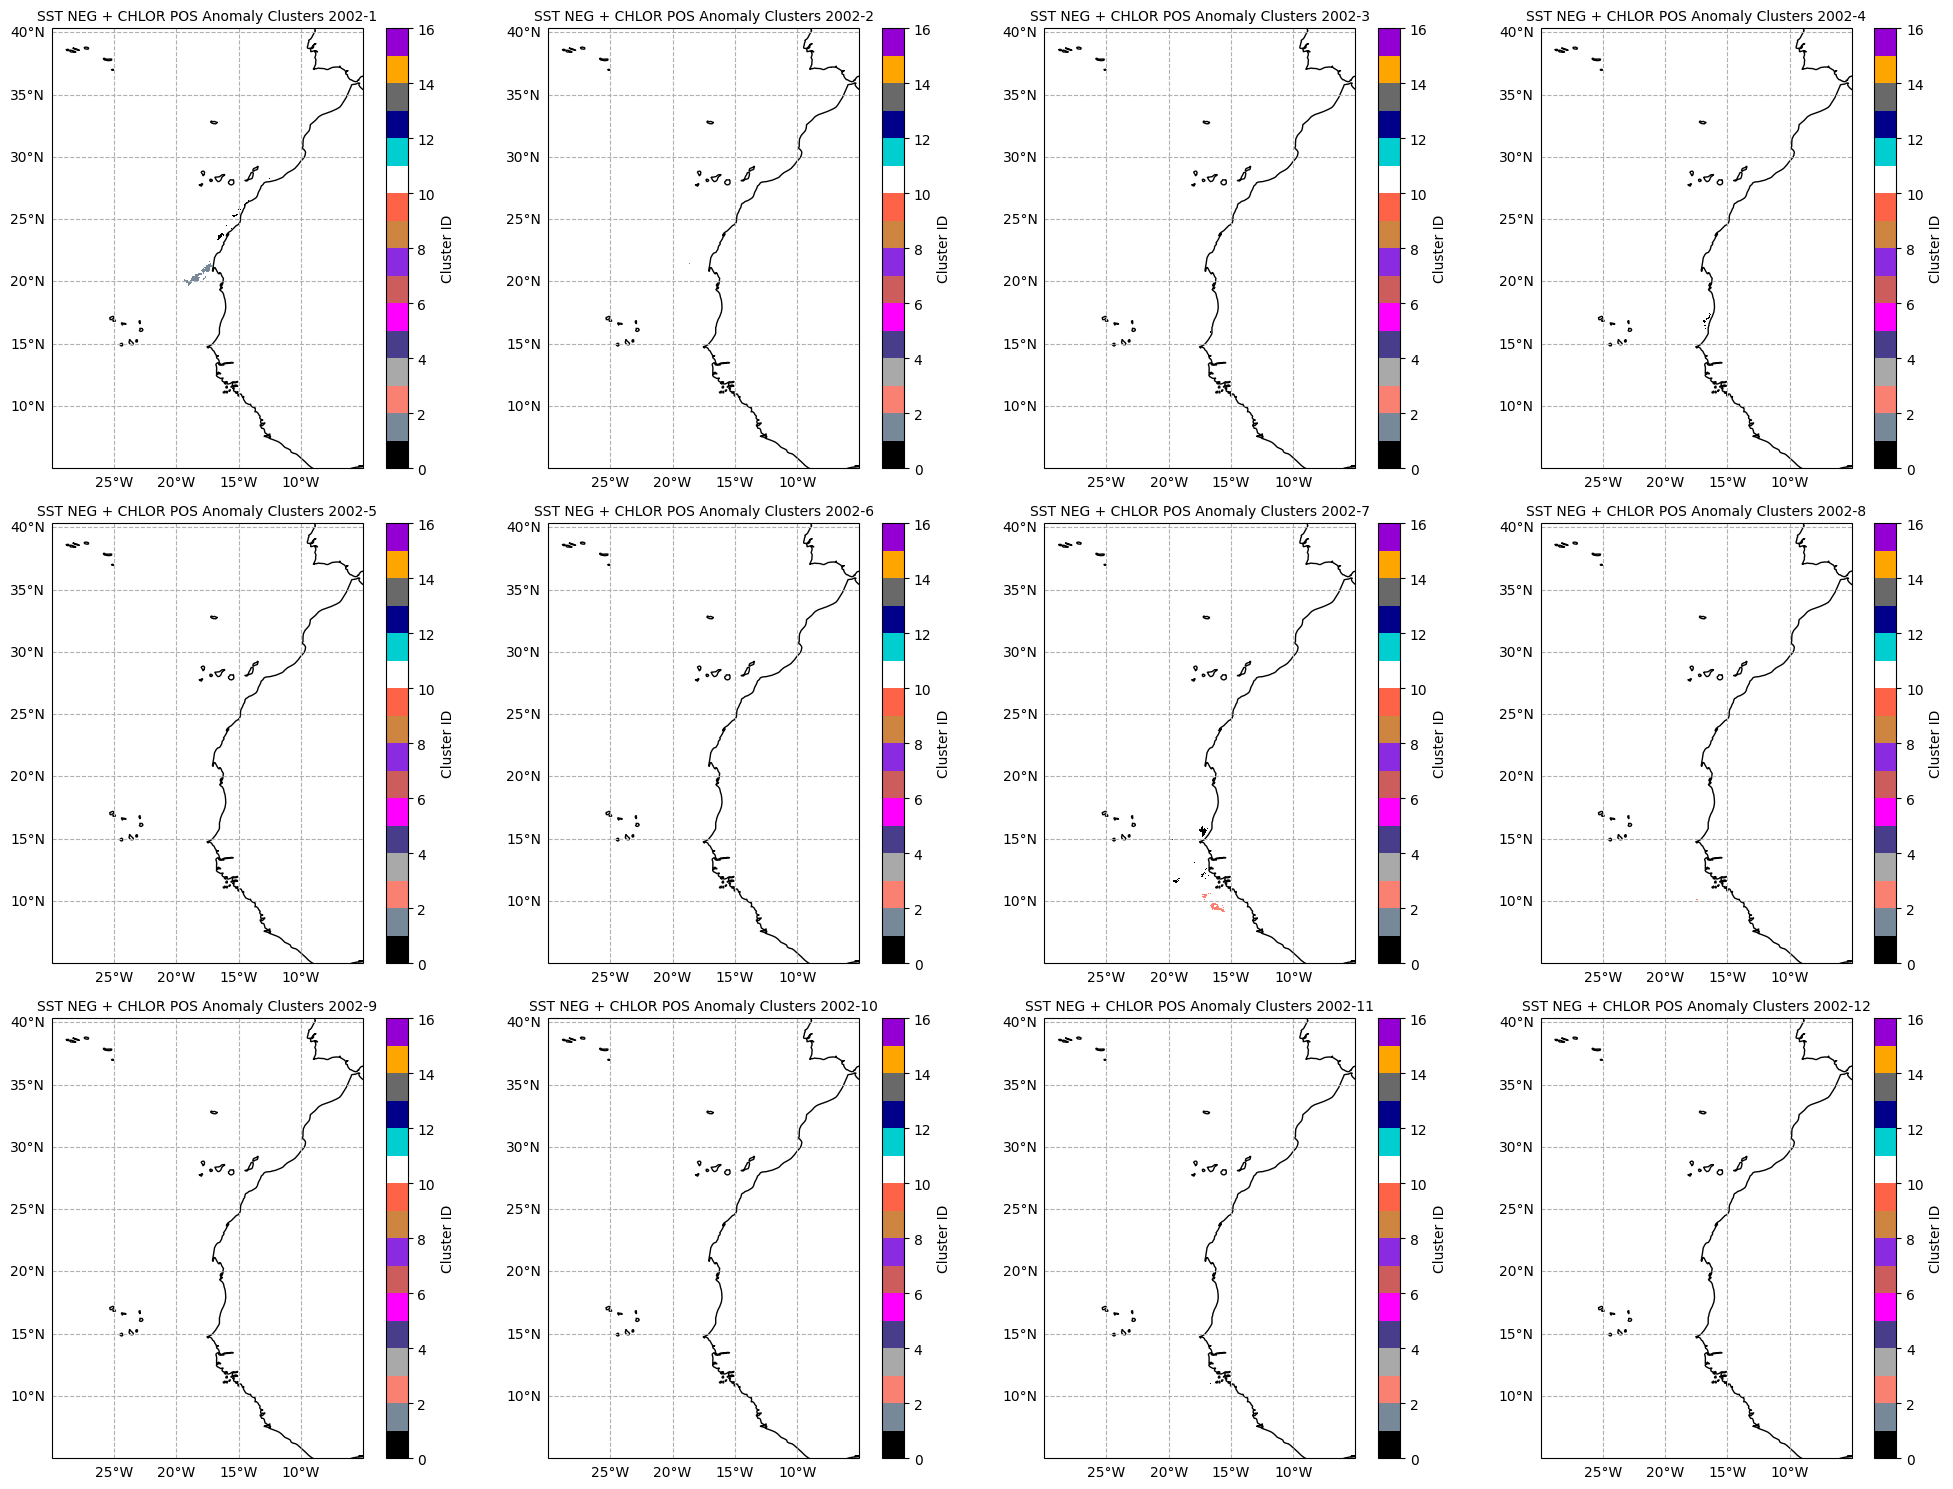

Experiment name: Smaller Min Neighbors
Found: 25 | Discarded: 0 | Runtime: 335.83 seconds
File name: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_1_40_40_100_1.pkl


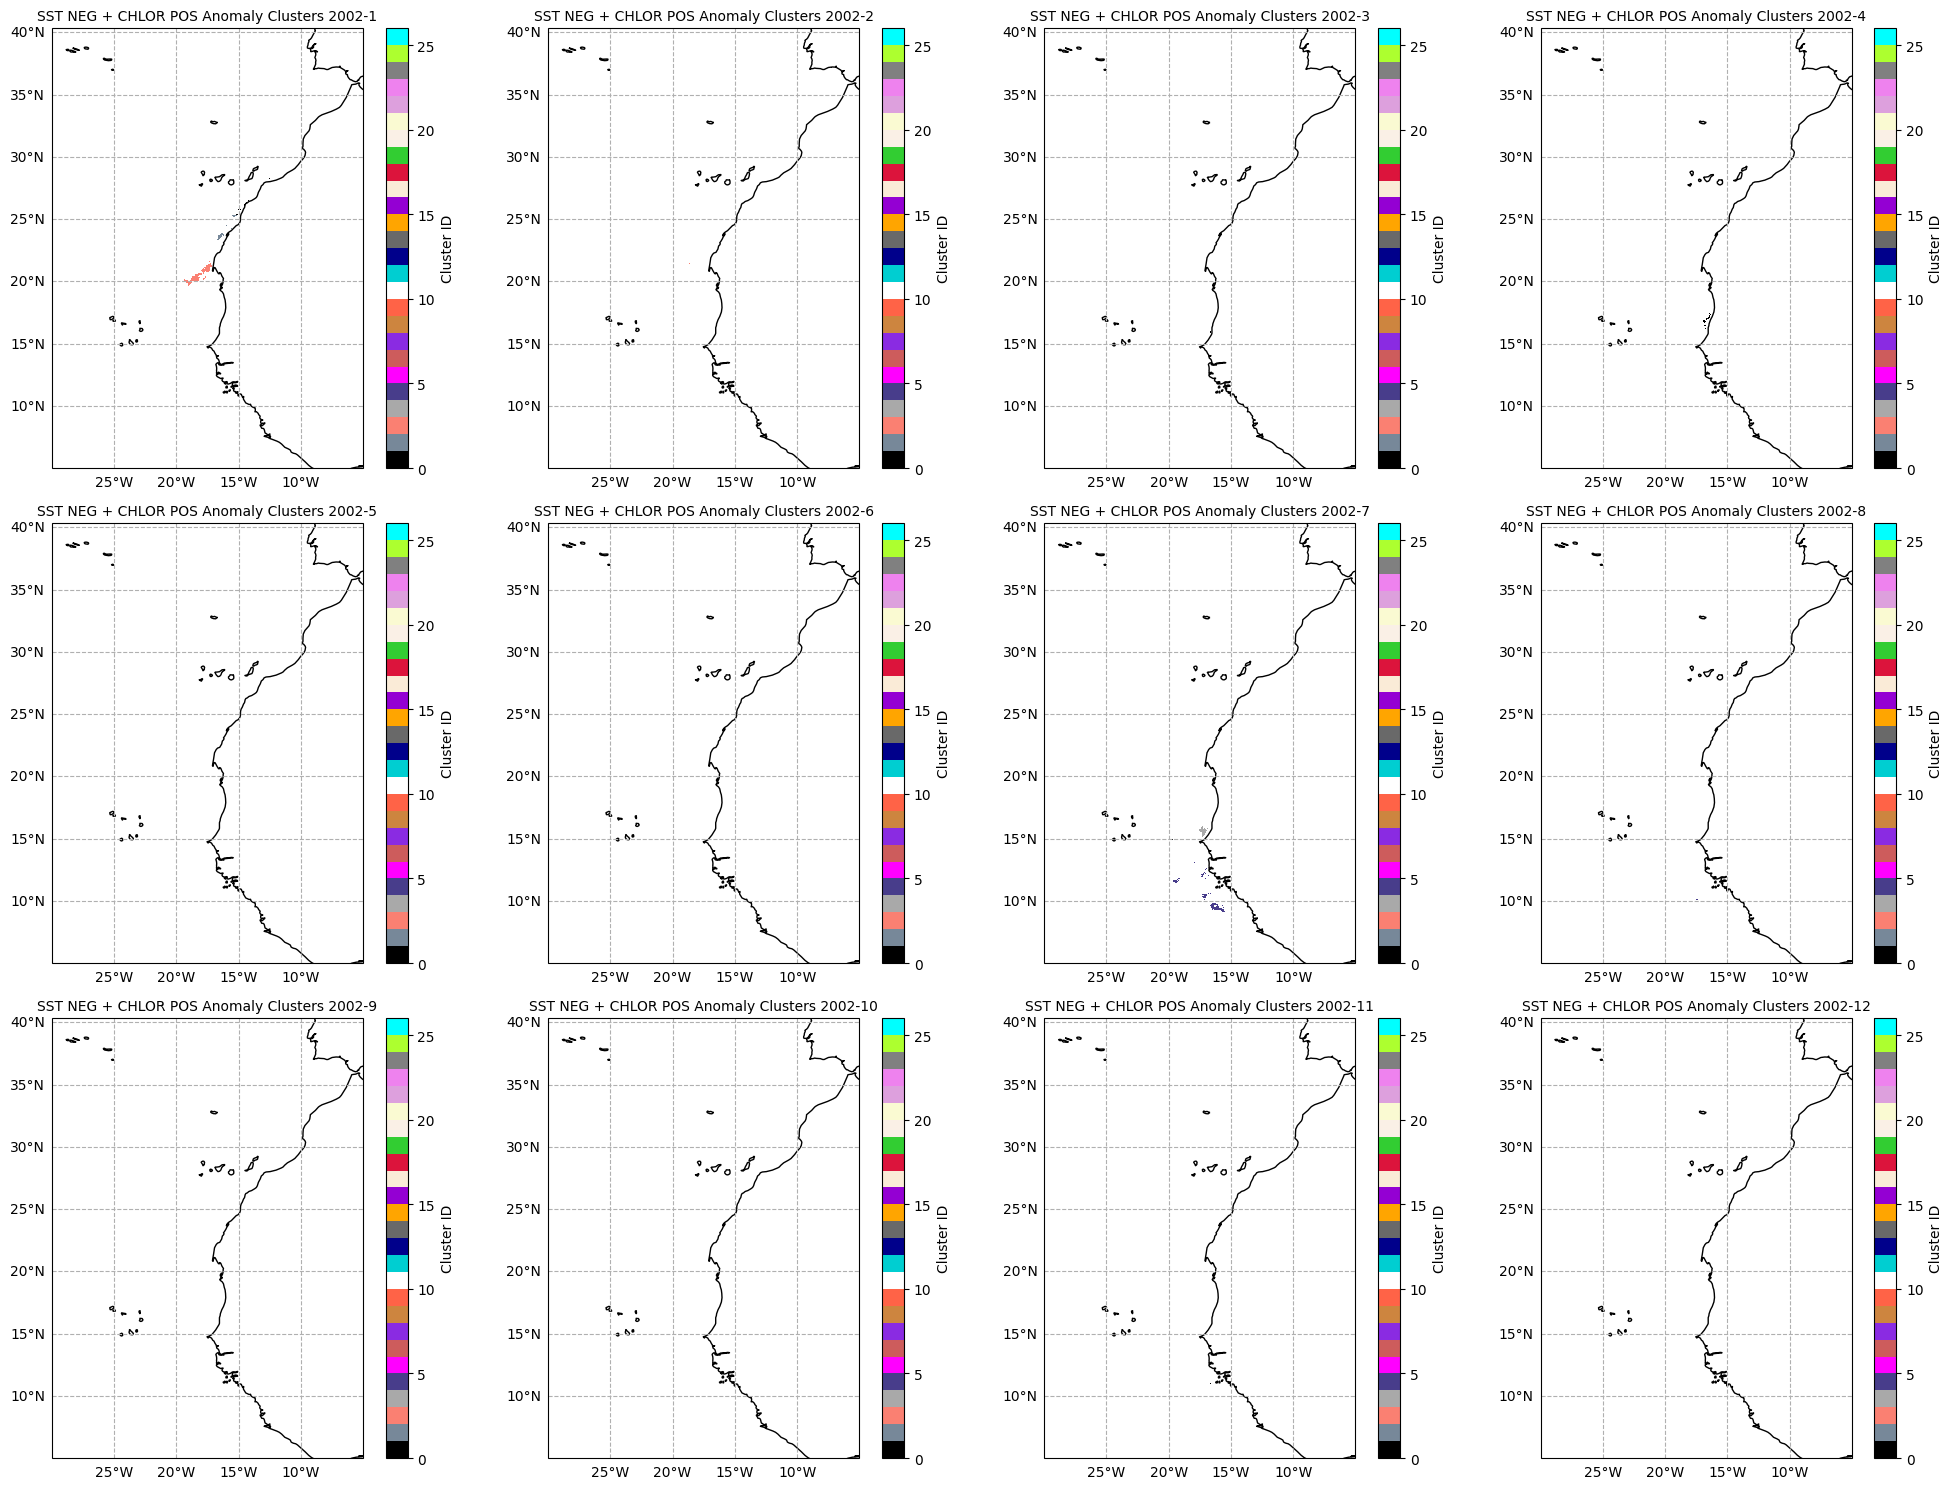

Experiment name: Larger Min Neighbors
Found: 10 | Discarded: 0 | Runtime: 484.08 seconds
File name: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_1_40_40_500_1.pkl


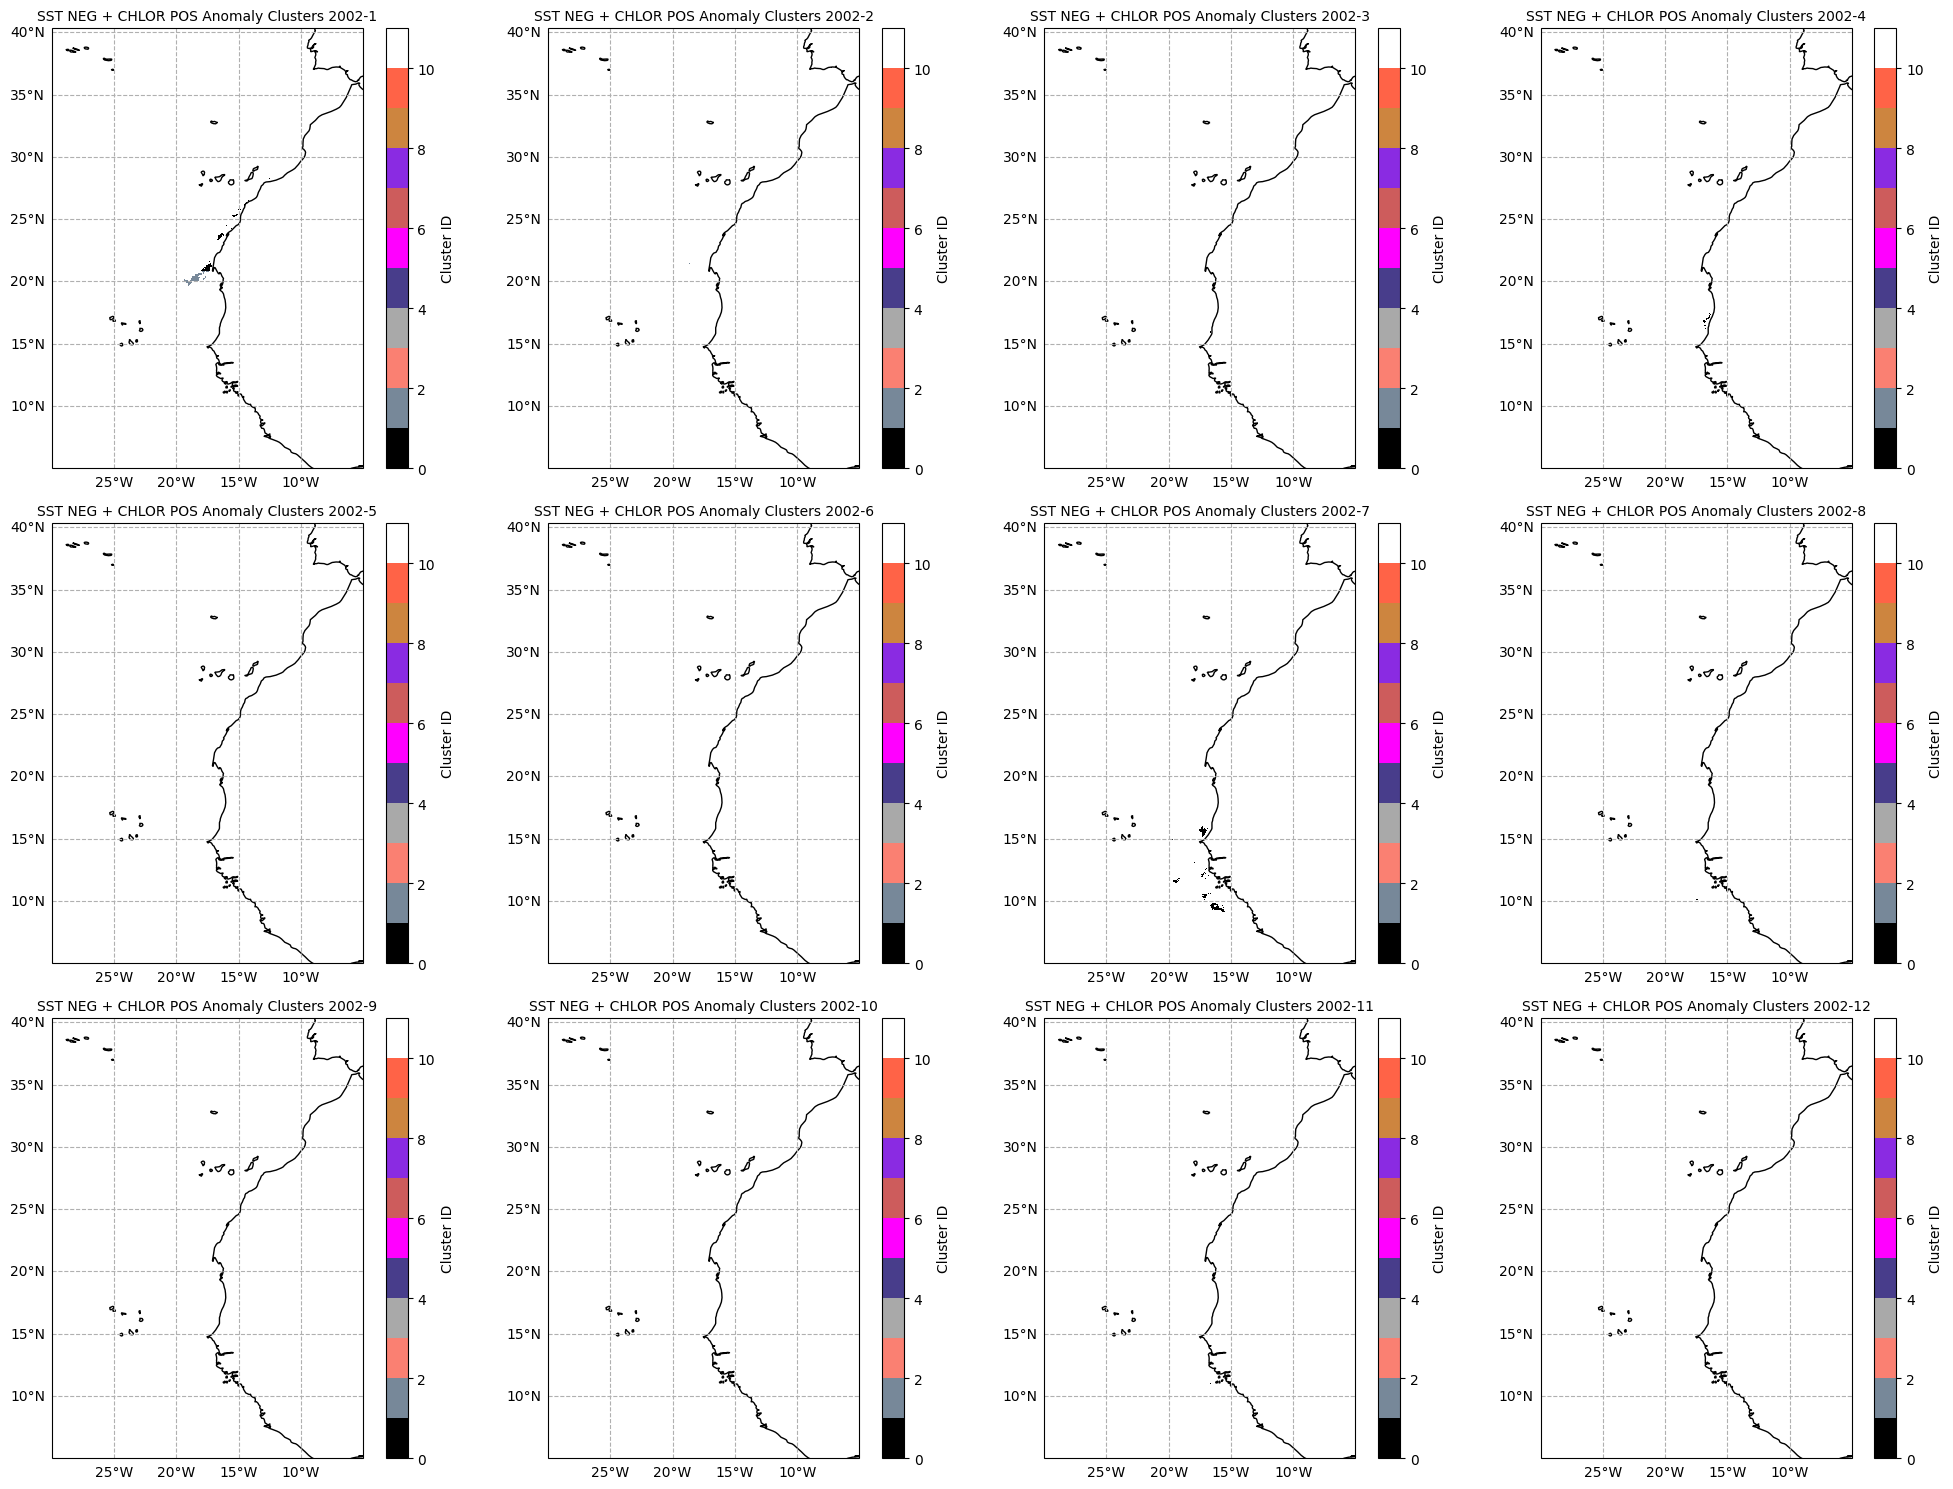

Experiment name: Much Larger Min Neighbors
Found: 4 | Discarded: 0 | Runtime: 415.56 seconds
File name: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_1_40_40_1000_1.pkl


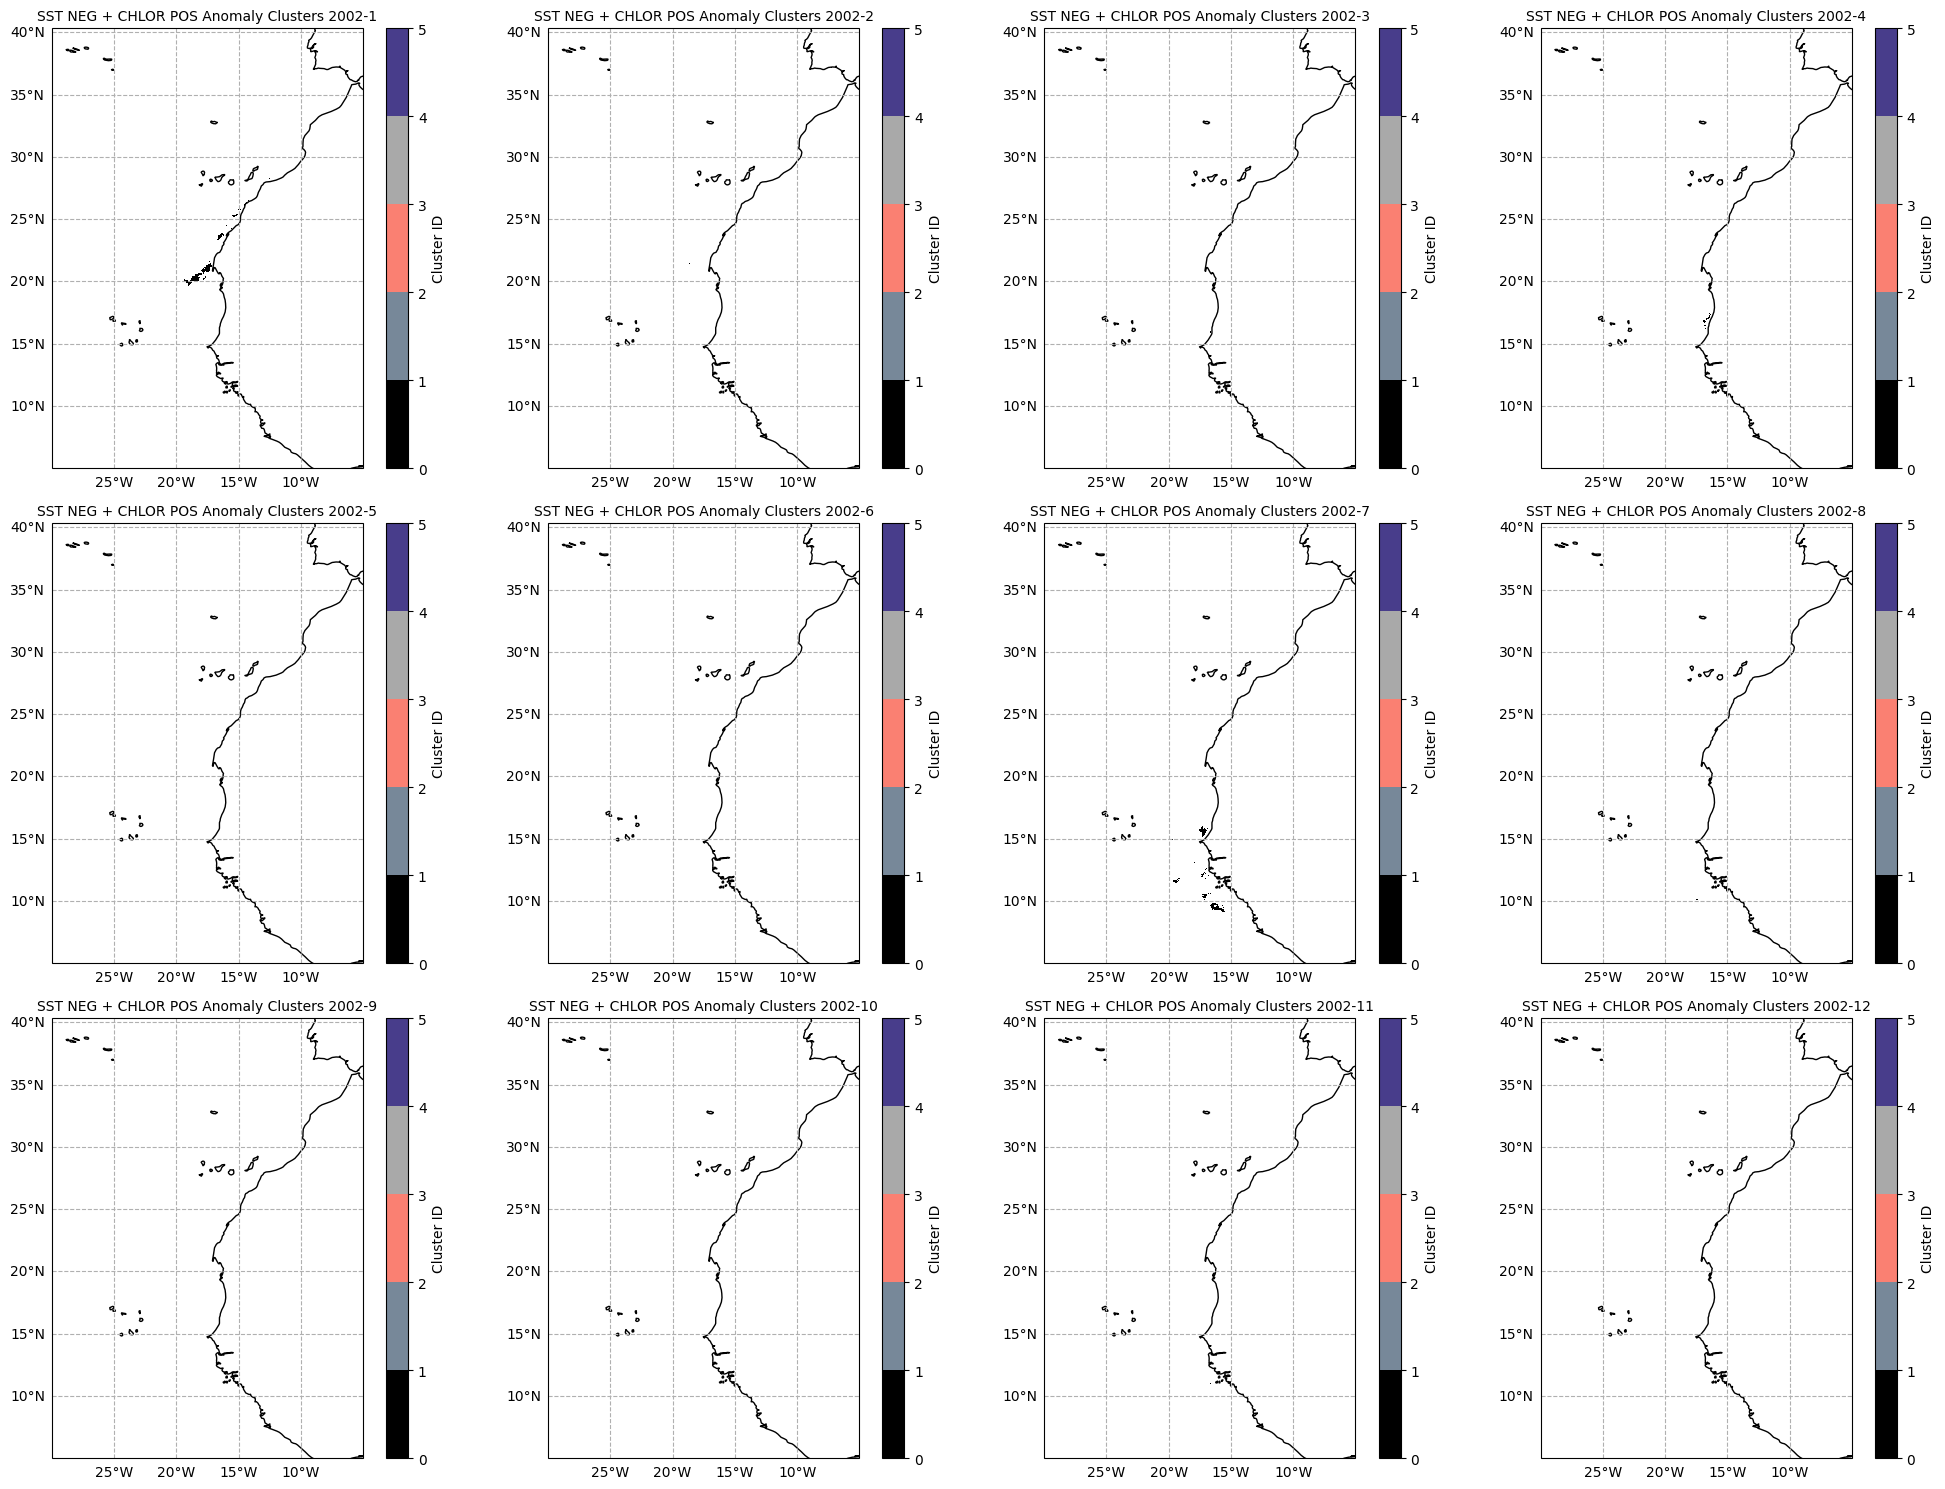

Experiment name: Smaller Geo Eps
Found: 11 | Discarded: 0 | Runtime: 188.50 seconds
File name: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_1_20_20_300_1.pkl


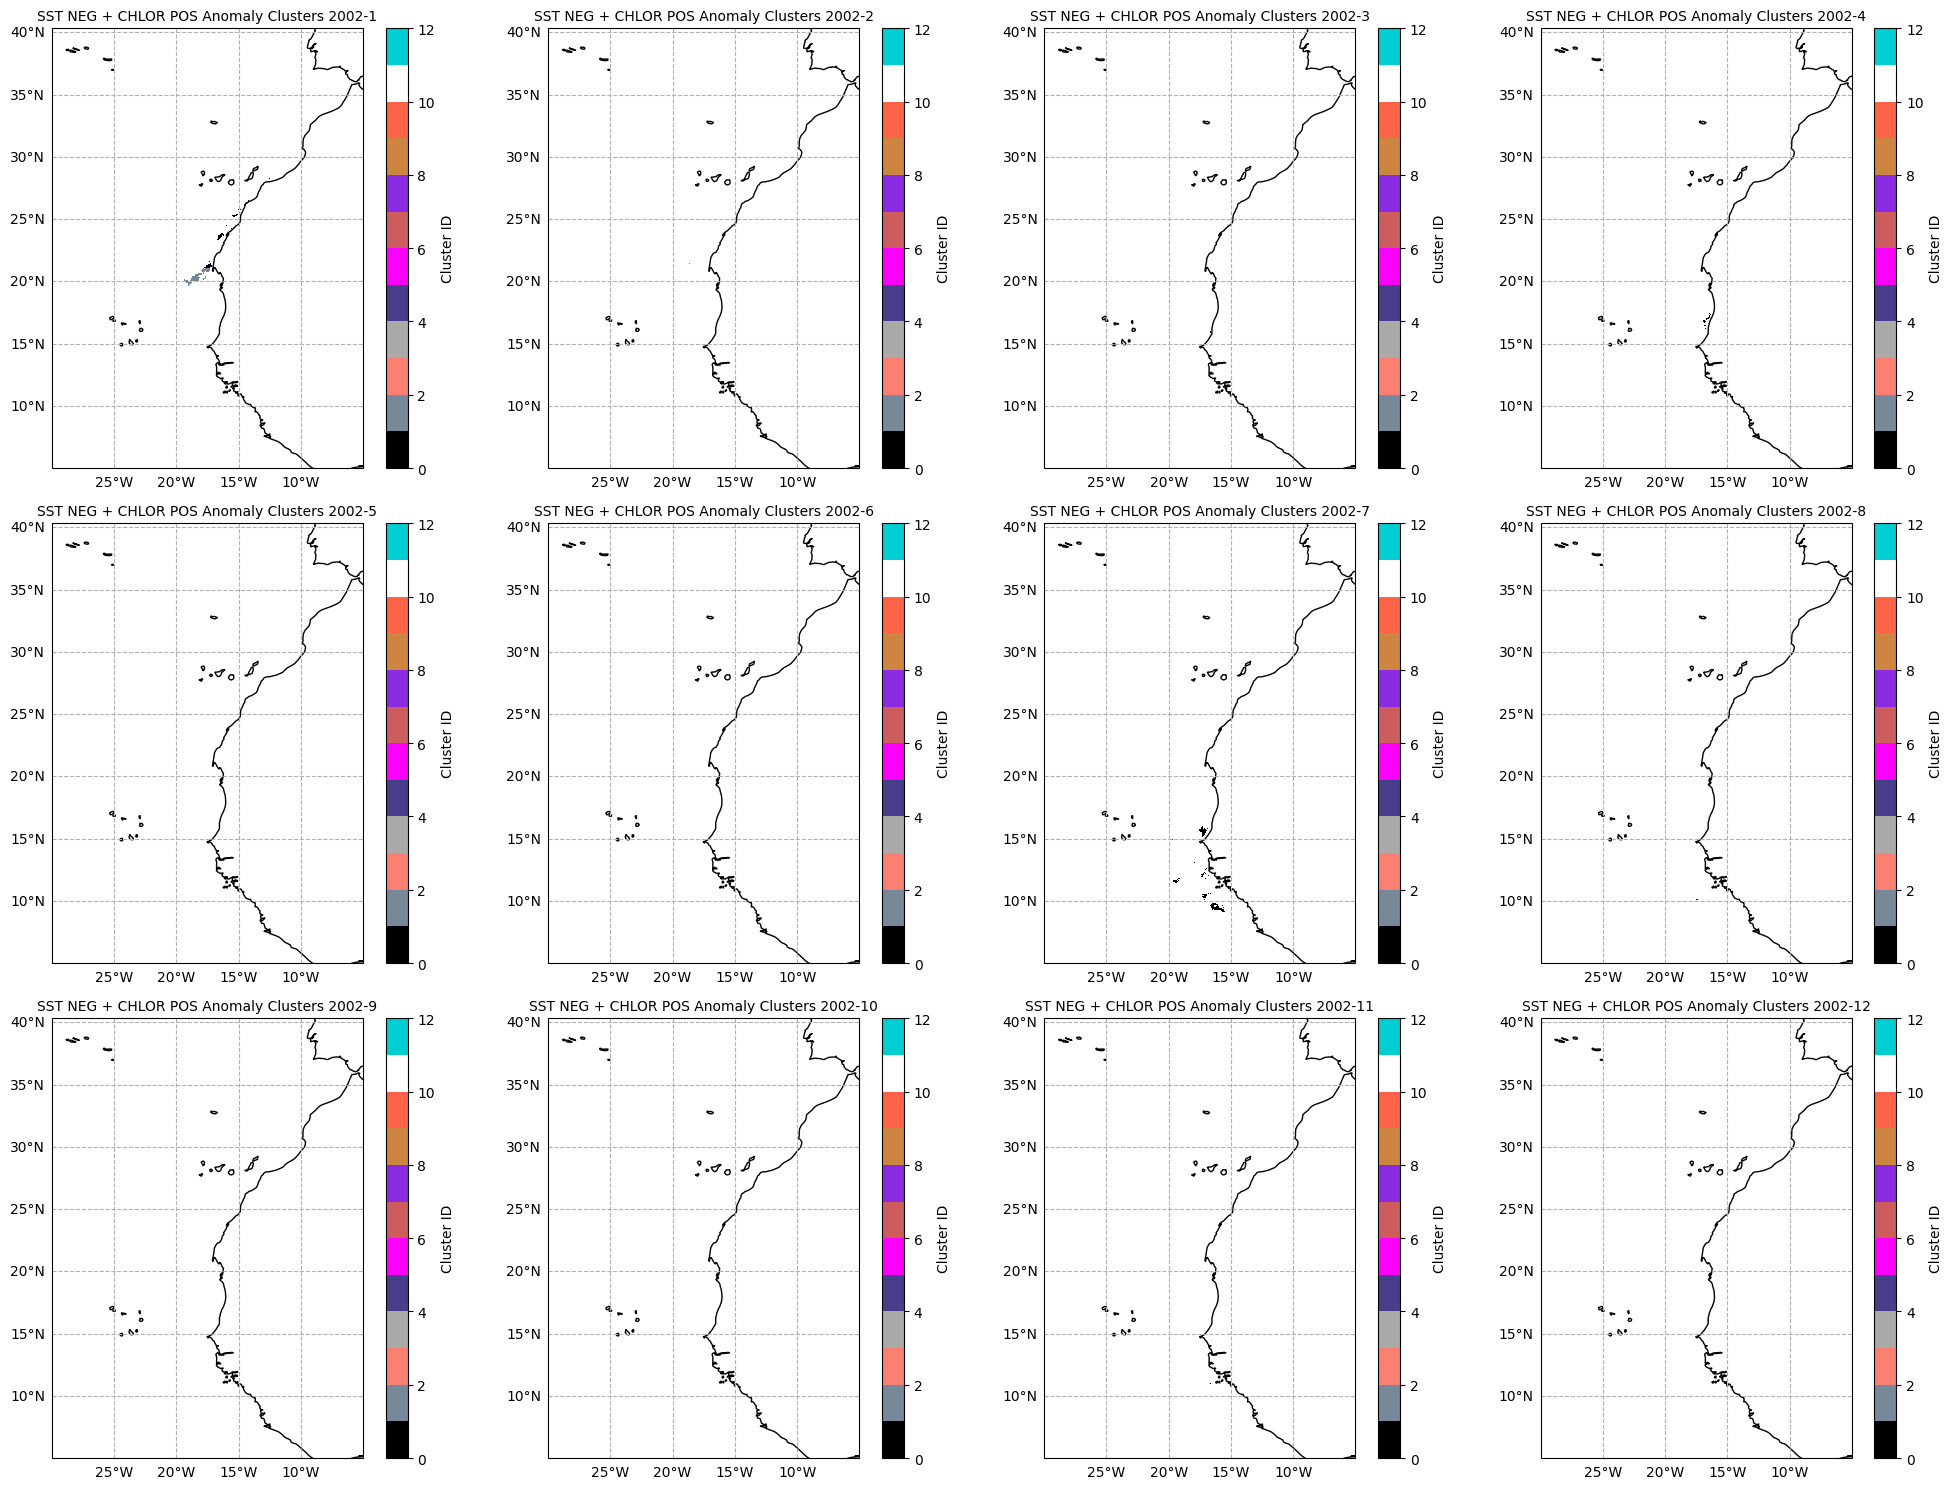

Experiment name: Larger Geo Eps
Found: 14 | Discarded: 0 | Runtime: 1073.14 seconds
File name: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_1_60_60_300_1.pkl


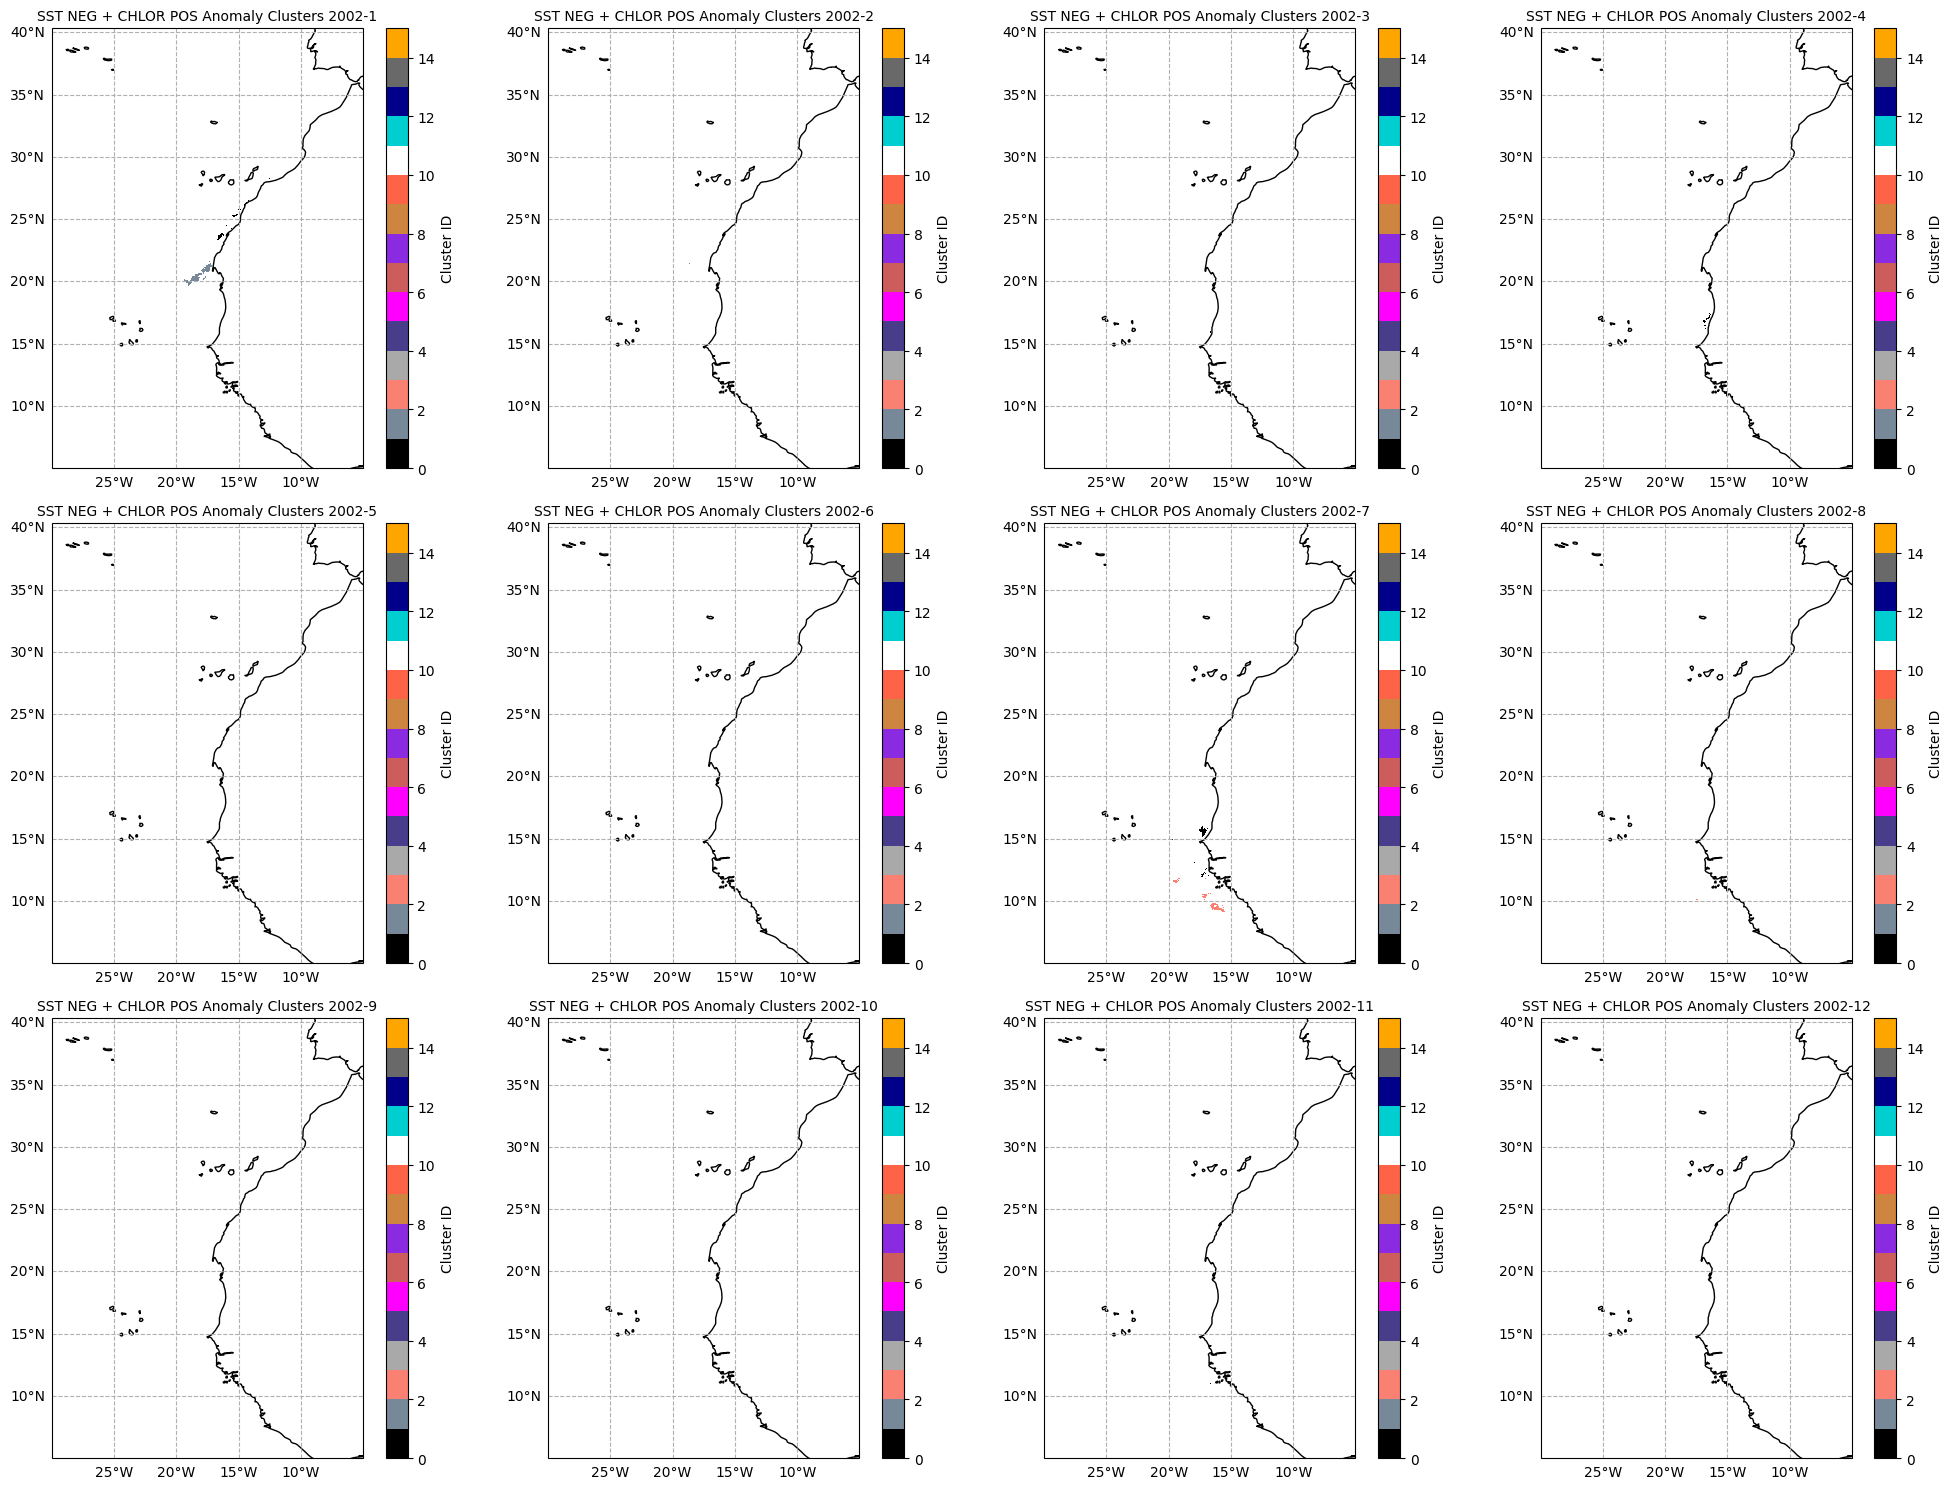

Experiment name: Larger Time Eps
Found: 11 | Discarded: 0 | Runtime: 766.96 seconds
File name: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_2_40_40_300_1.pkl


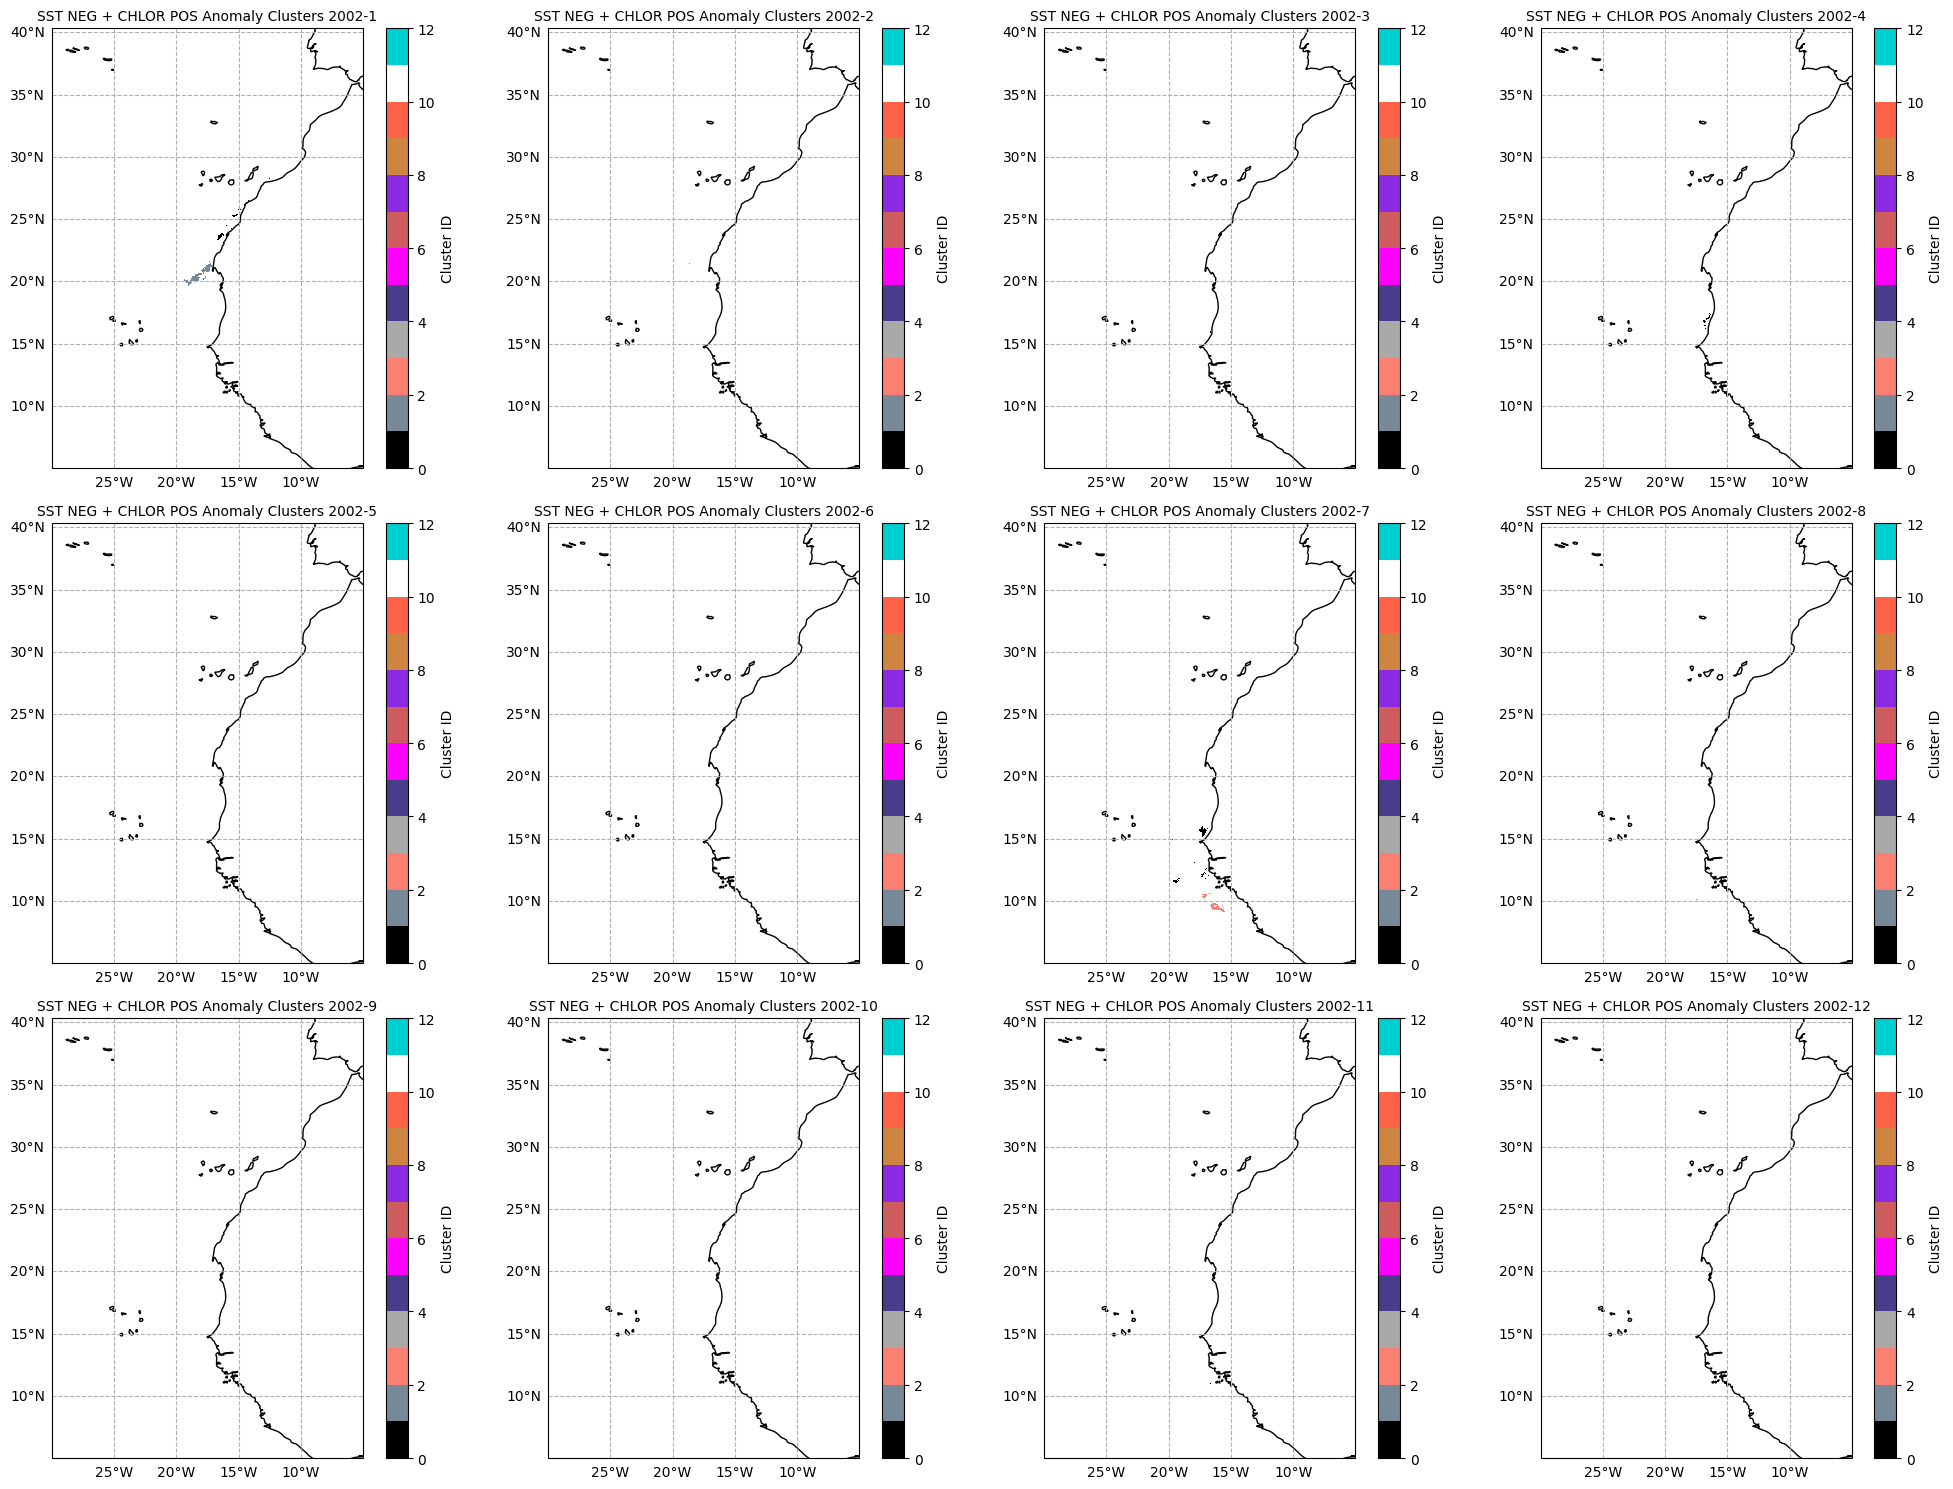

Experiment name: Much Larger Time Eps
Found: 6 | Discarded: 0 | Runtime: 1564.51 seconds
File name: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_12_40_40_300_1.pkl


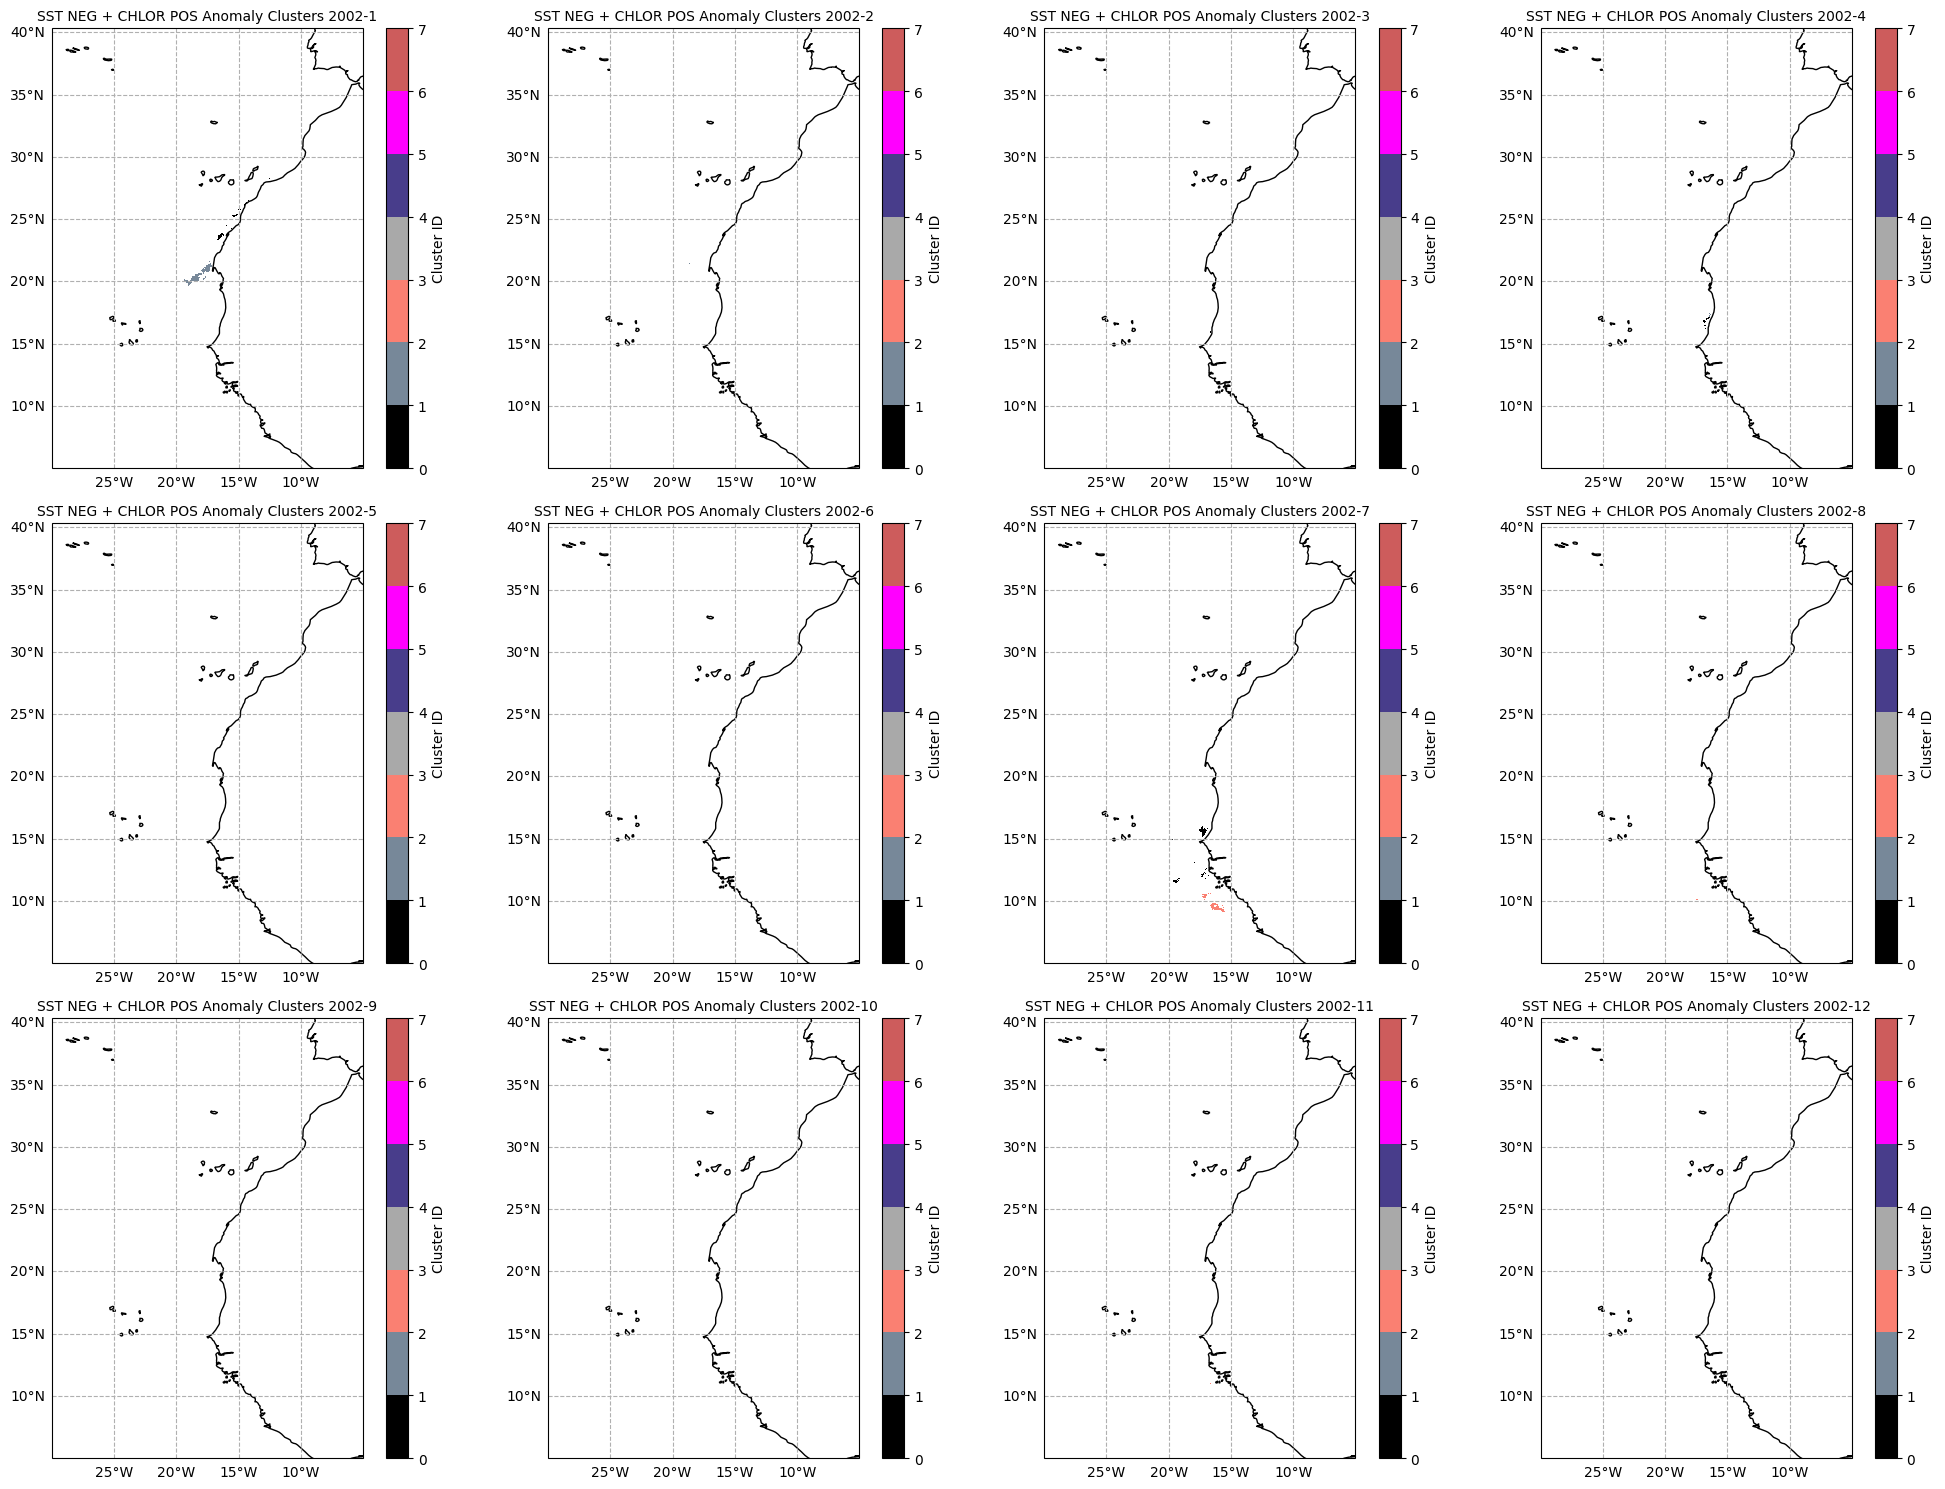

Experiment name: (2) Base Full Period
Found: 6 | Discarded: 0 | Runtime: 88.37 seconds
File name: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_1_20_20_500_1.pkl


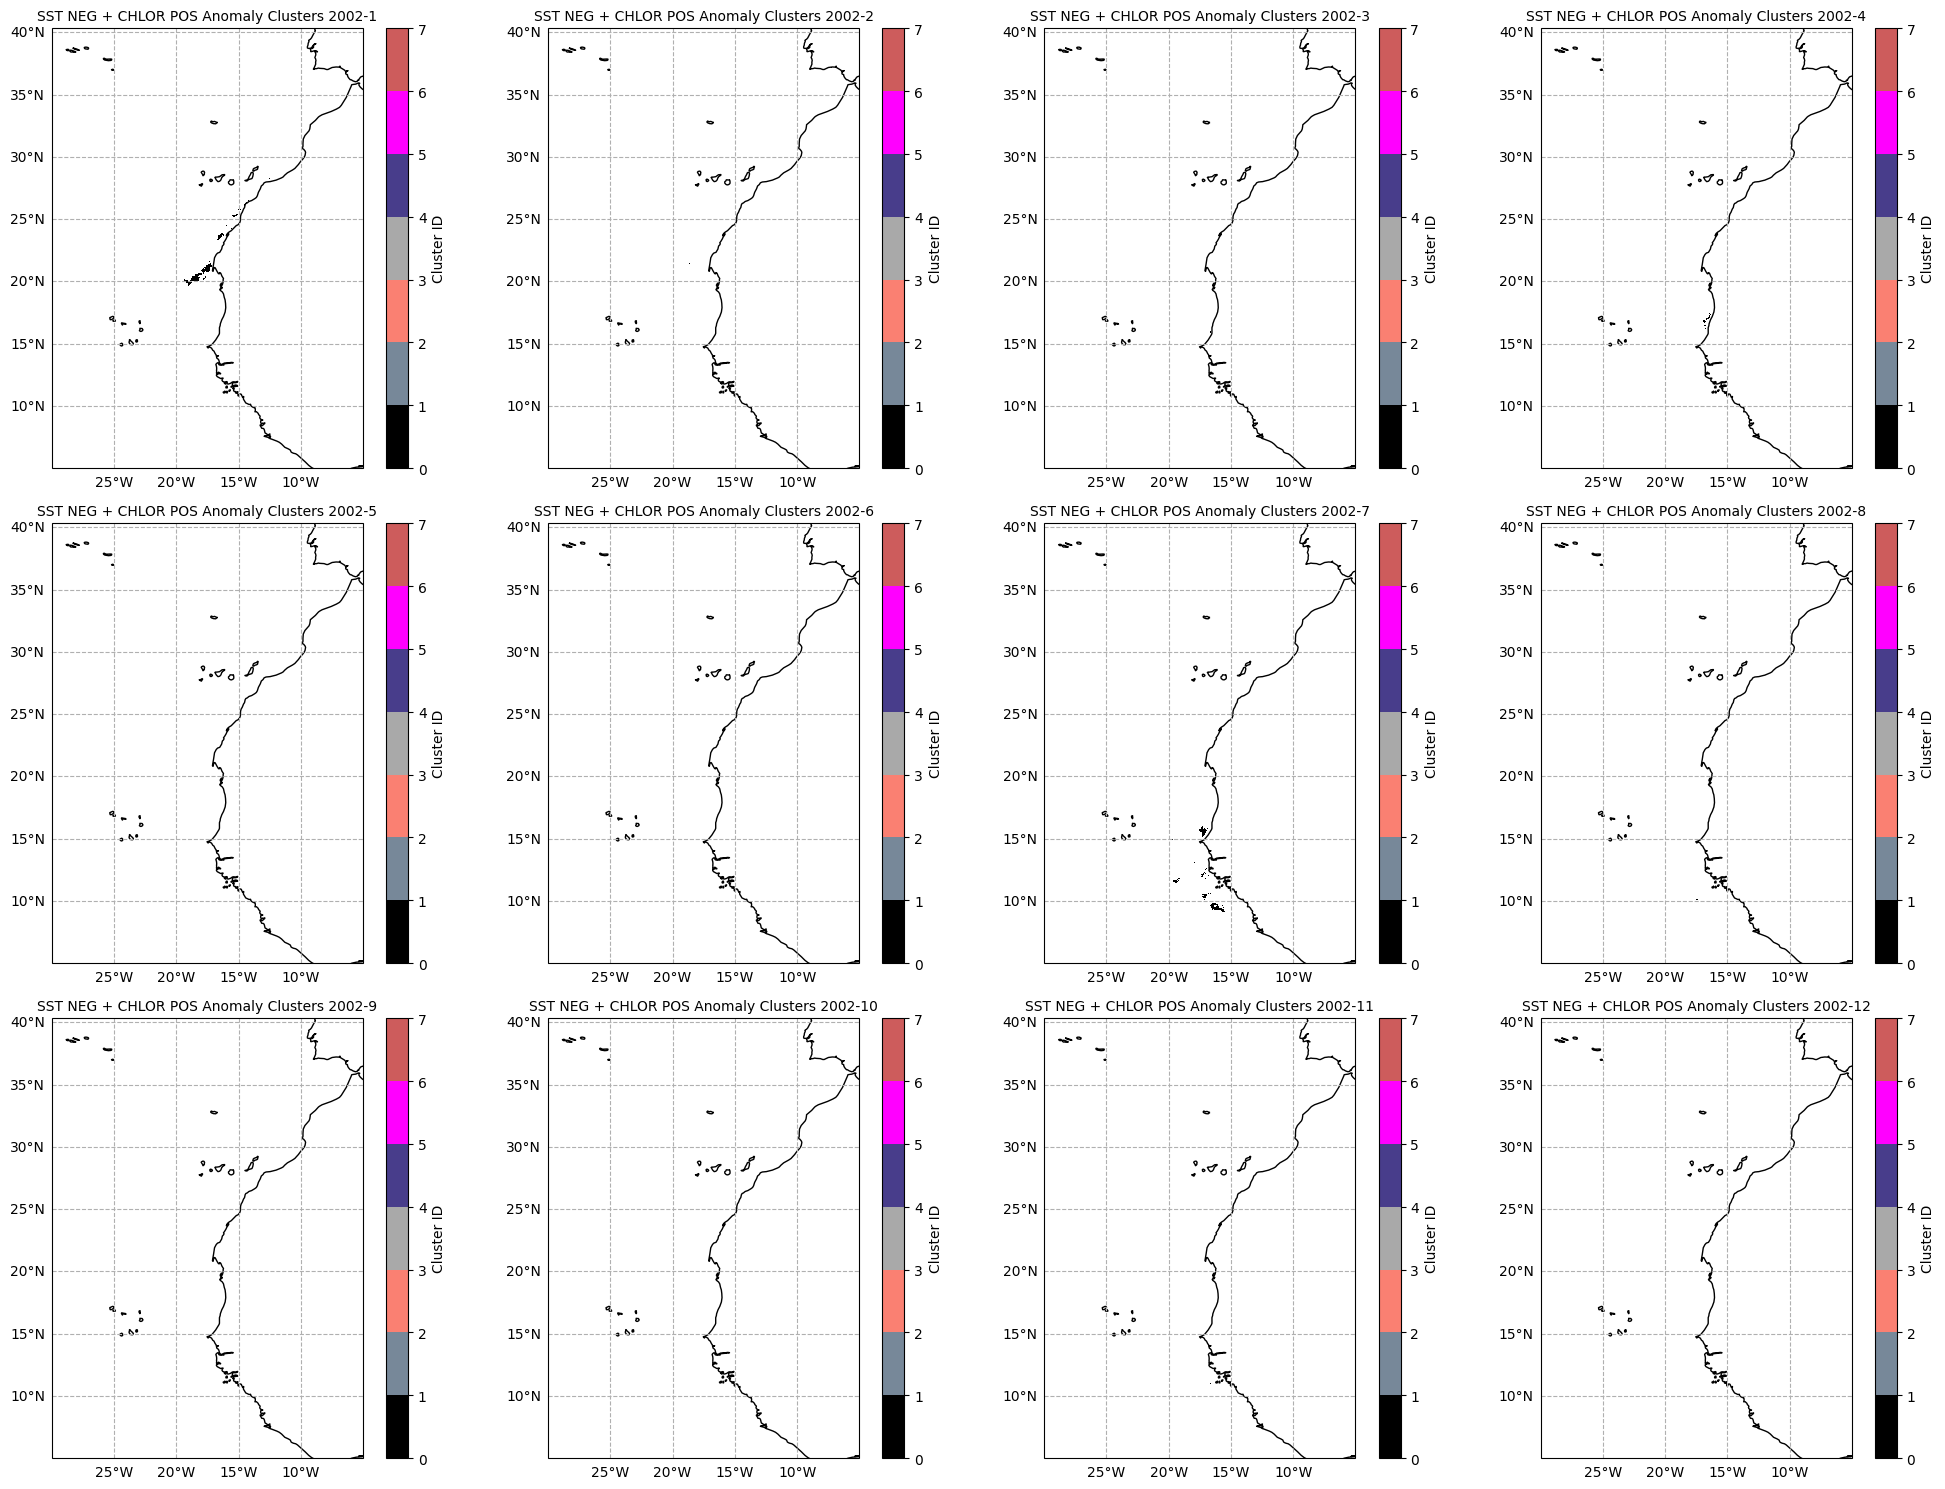

Experiment name: (2) Smaller Min Neighbors
Found: 18 | Discarded: 0 | Runtime: 105.12 seconds
File name: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_1_20_20_250_1.pkl


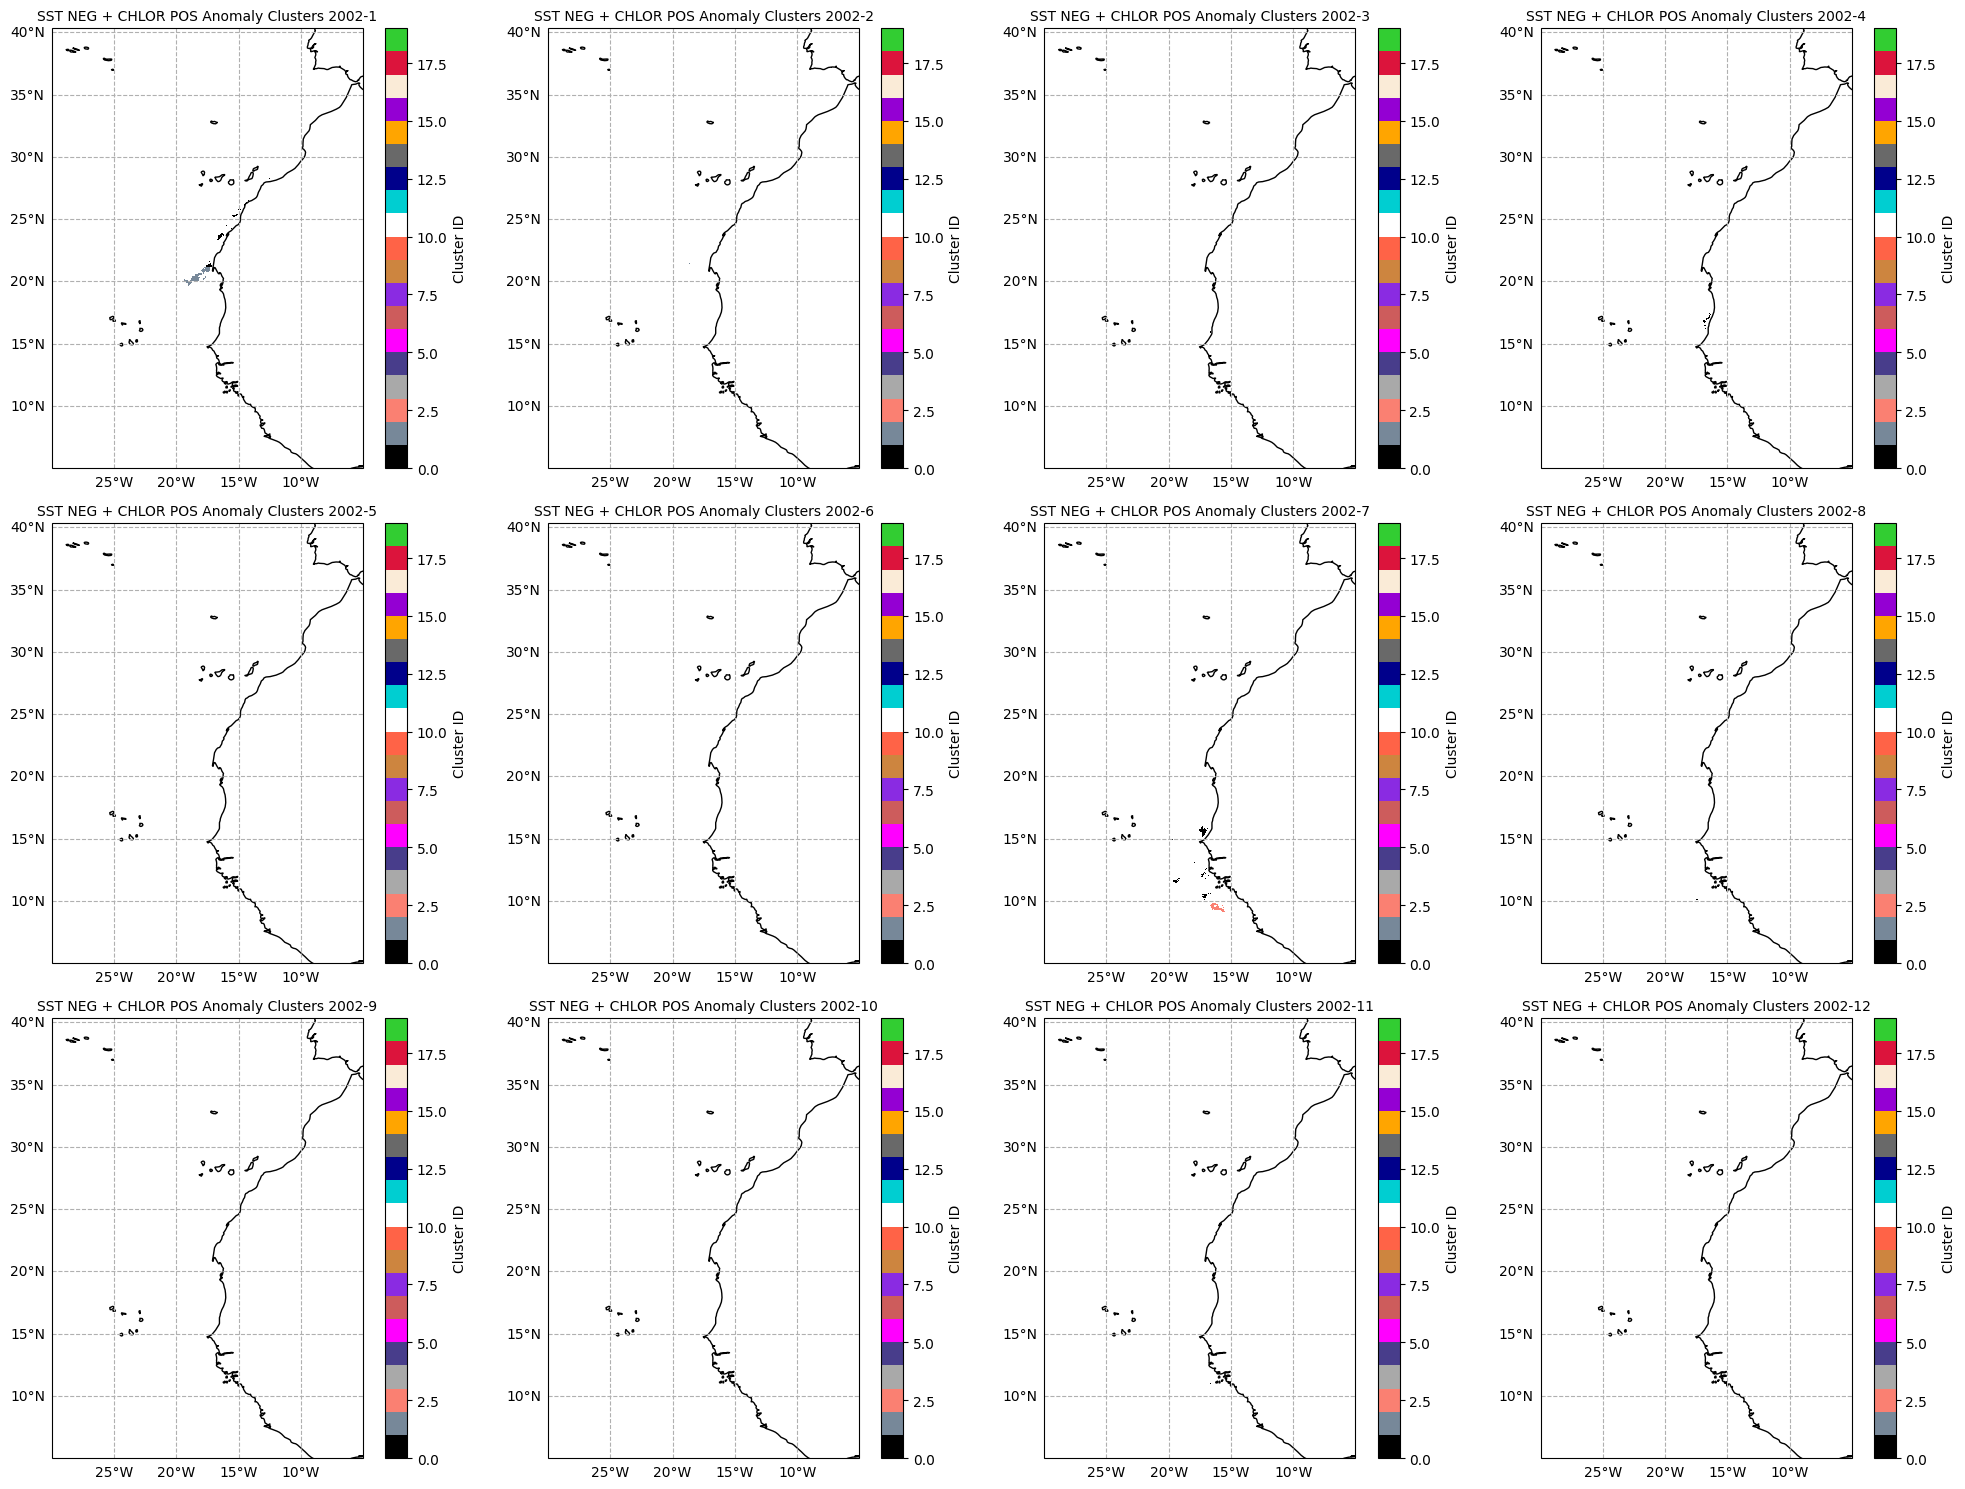

Experiment name: (2) Larger Min Neighbors
Found: 2 | Discarded: 0 | Runtime: 70.43 seconds
File name: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_1_20_20_750_1.pkl


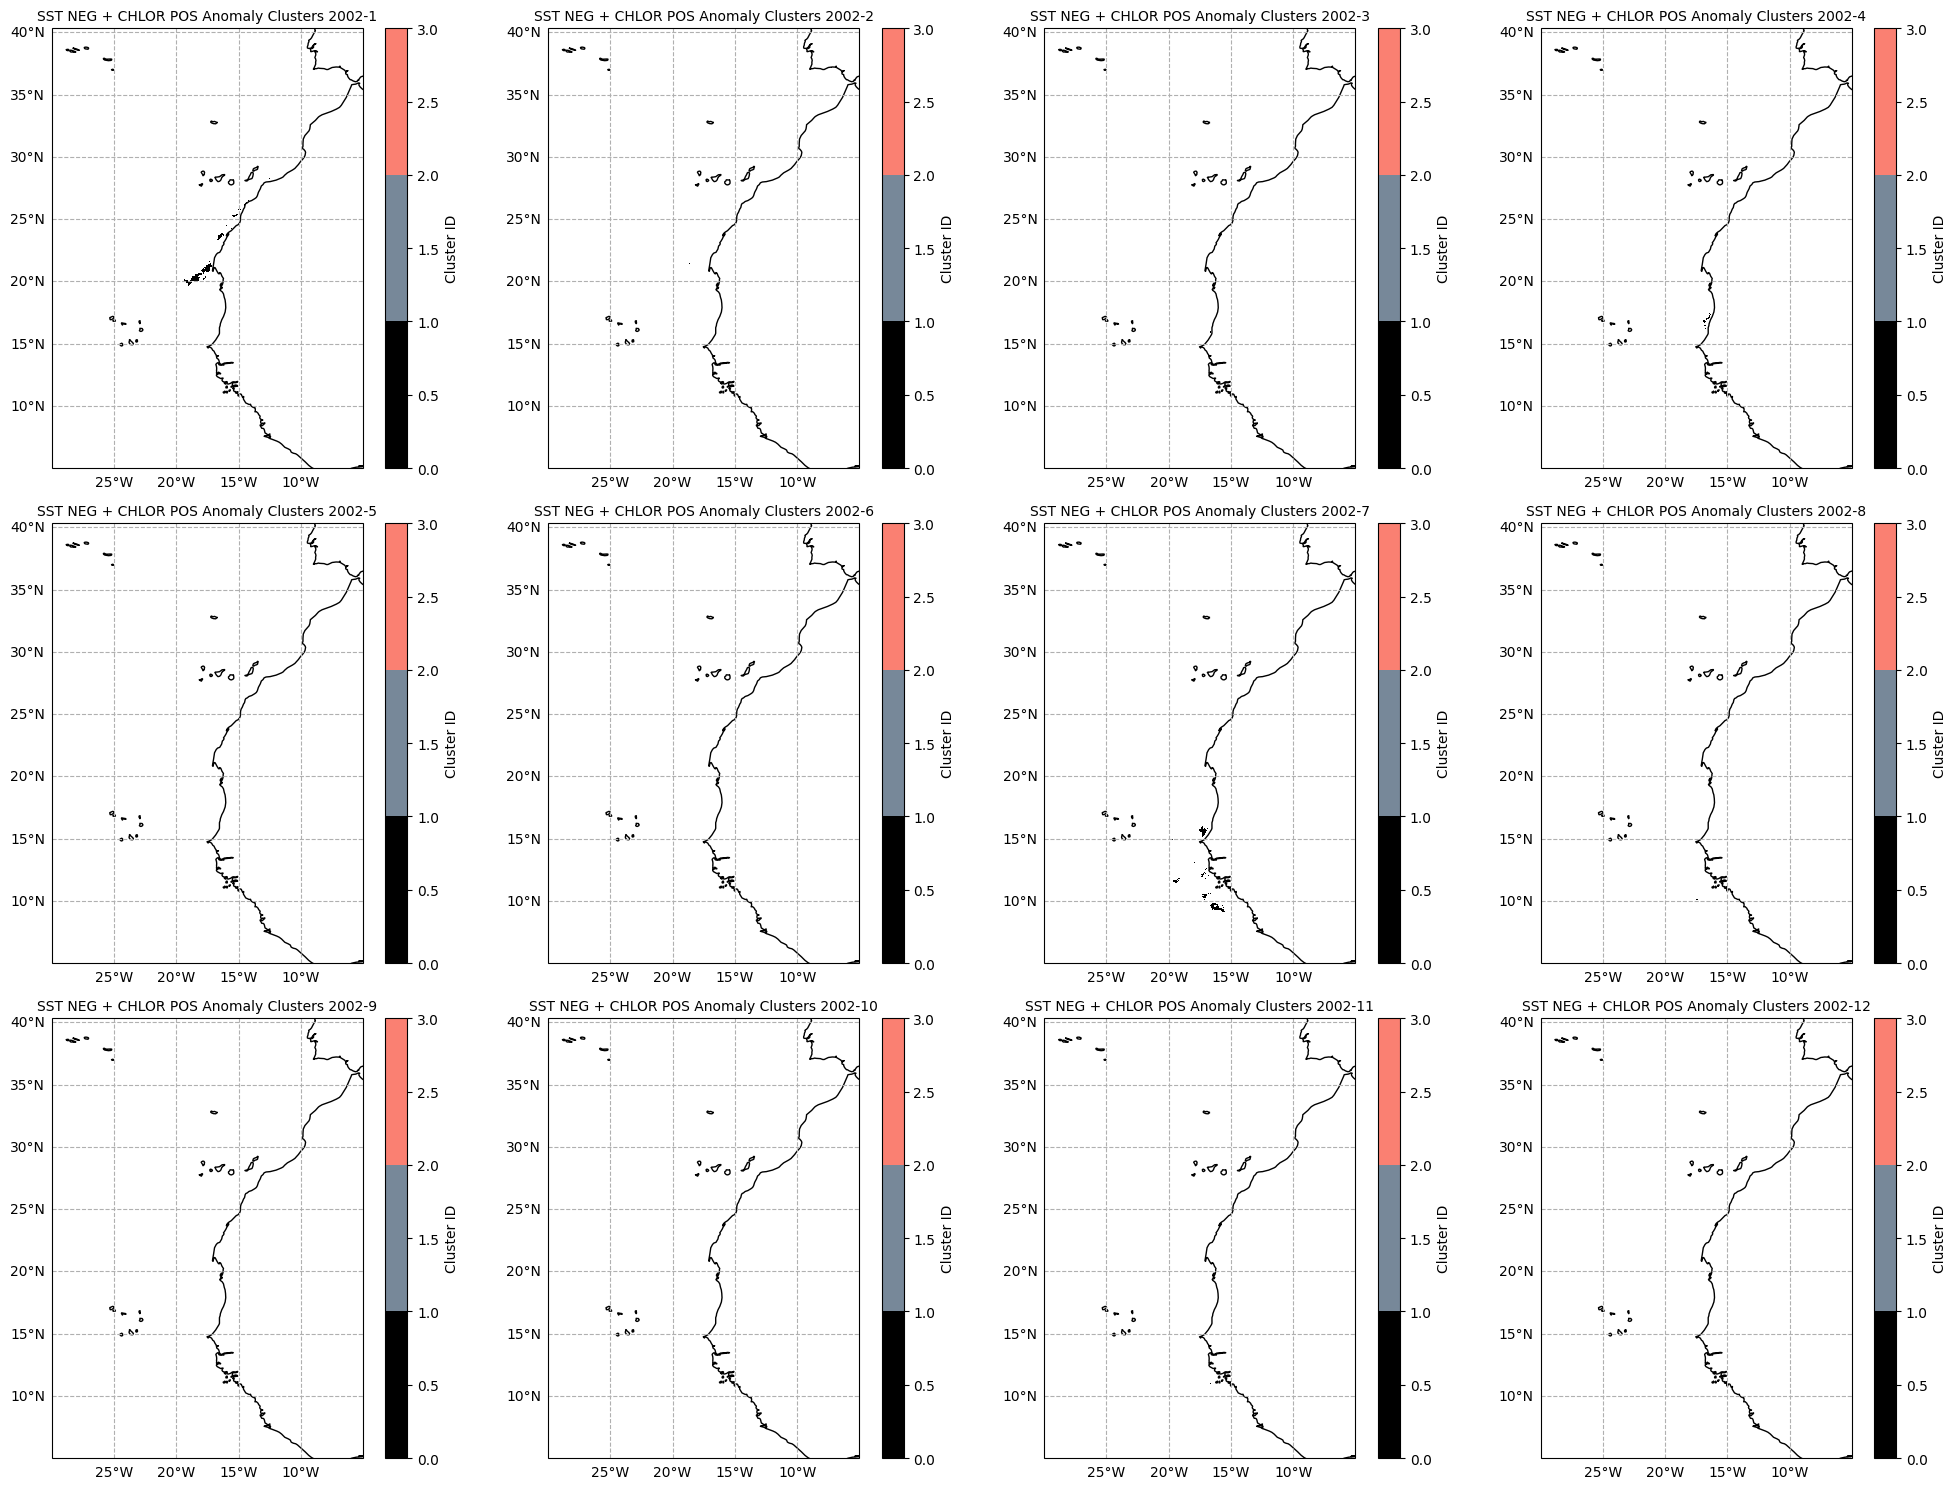

Experiment name: (2) Much Larger Min Neighbors
Found: 1 | Discarded: 0 | Runtime: 60.93 seconds
File name: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_1_20_20_1000_1.pkl


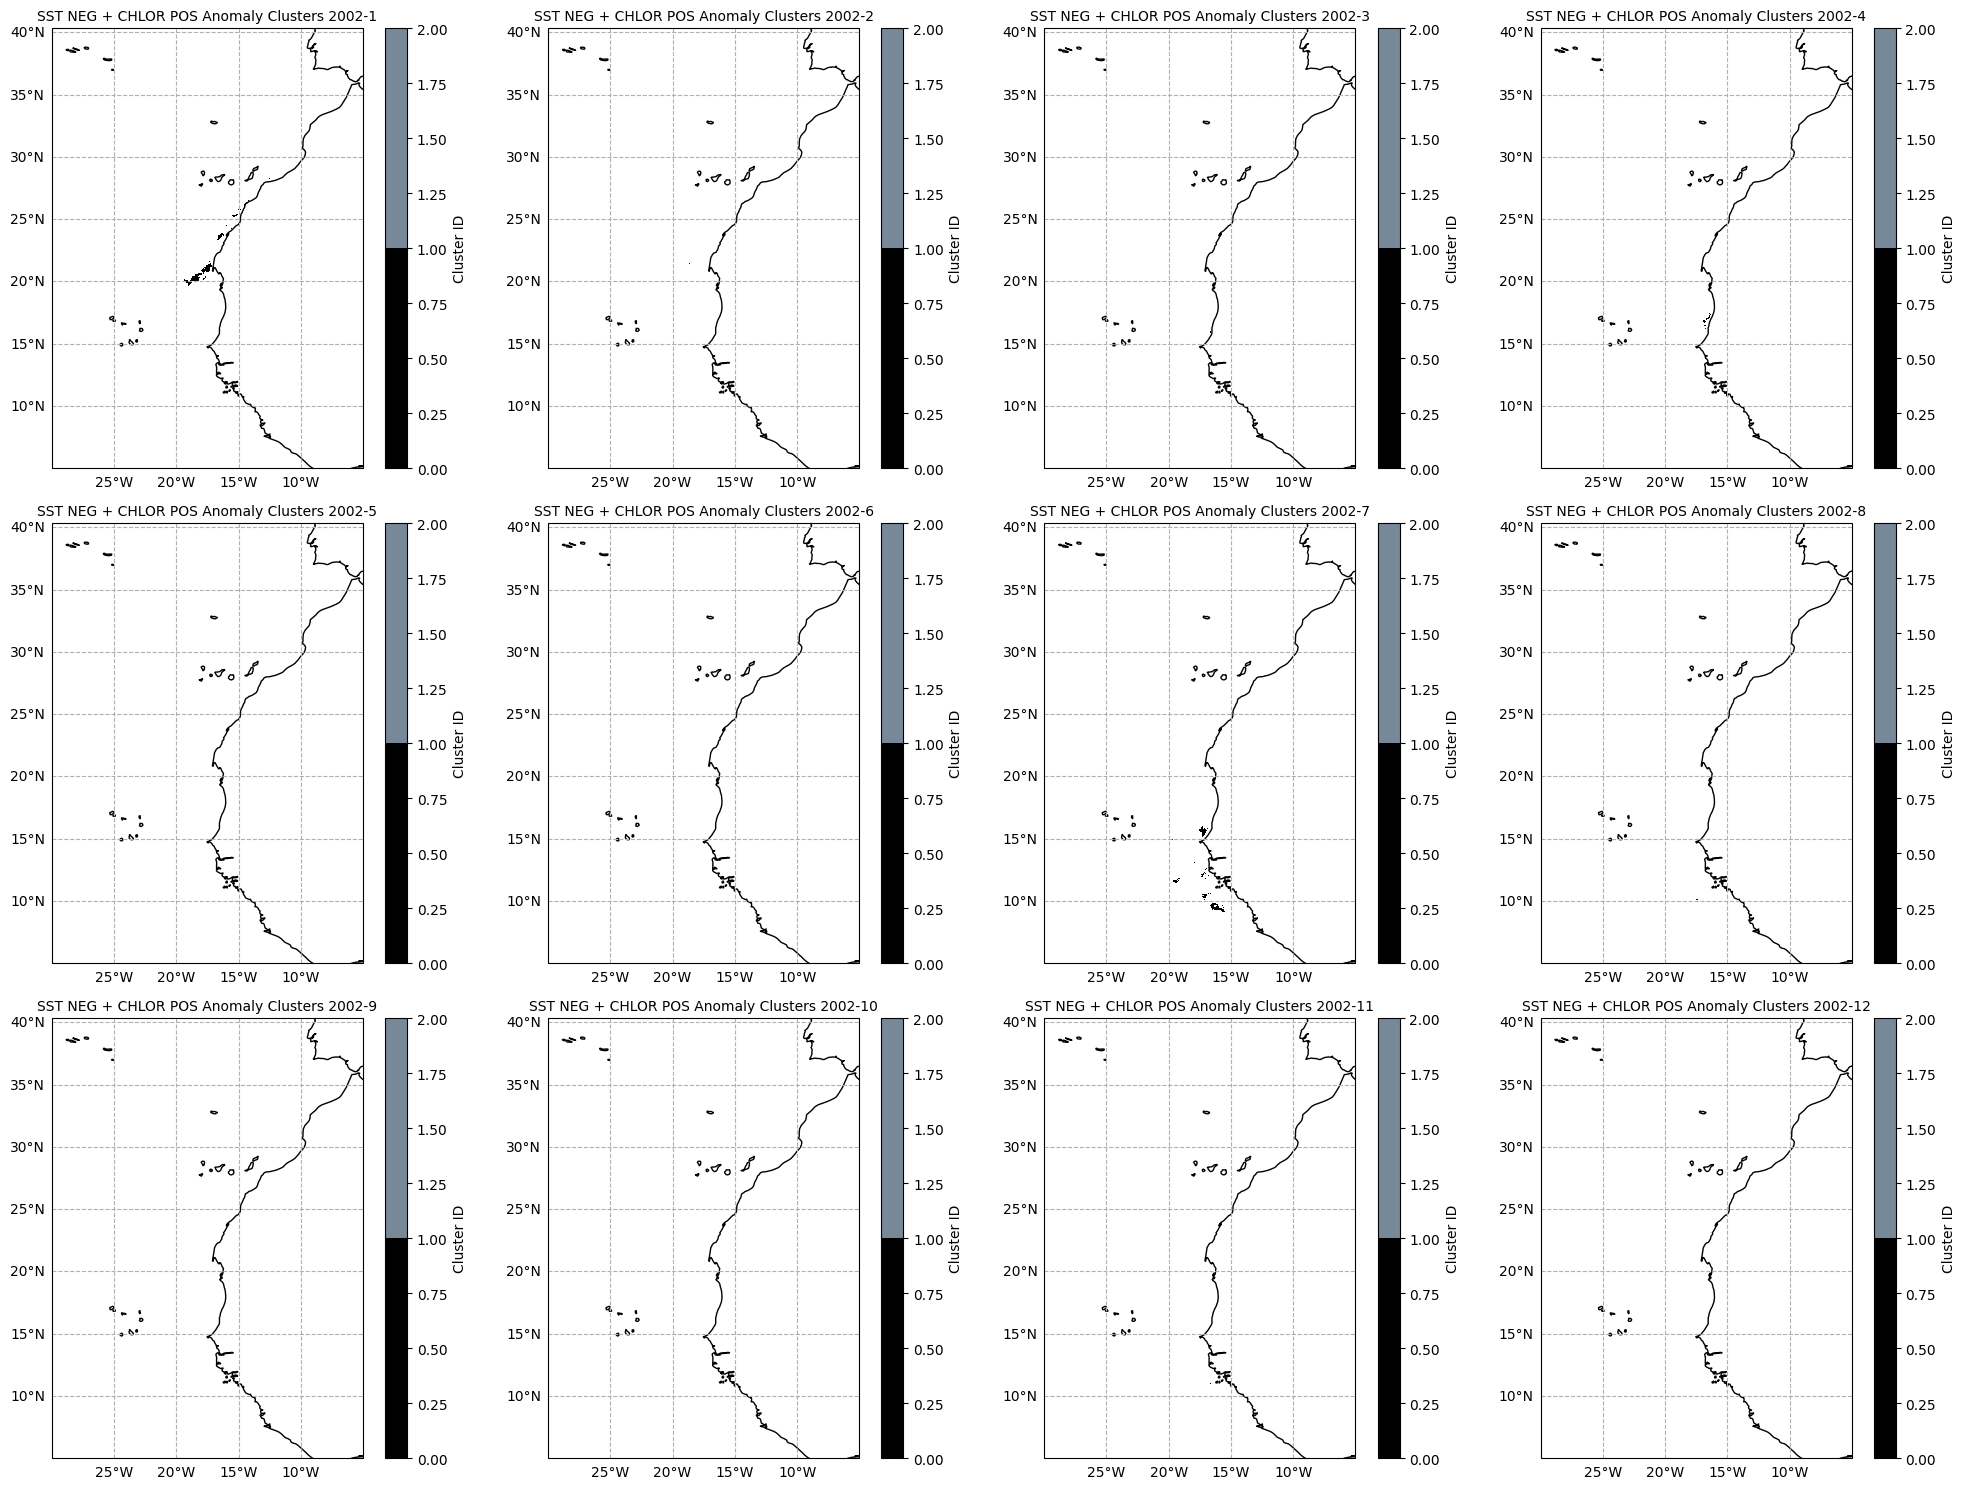

Experiment name: (2) Smaller Geo Eps
Found: 1 | Discarded: 0 | Runtime: 23.24 seconds
File name: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_1_10_10_500_1.pkl


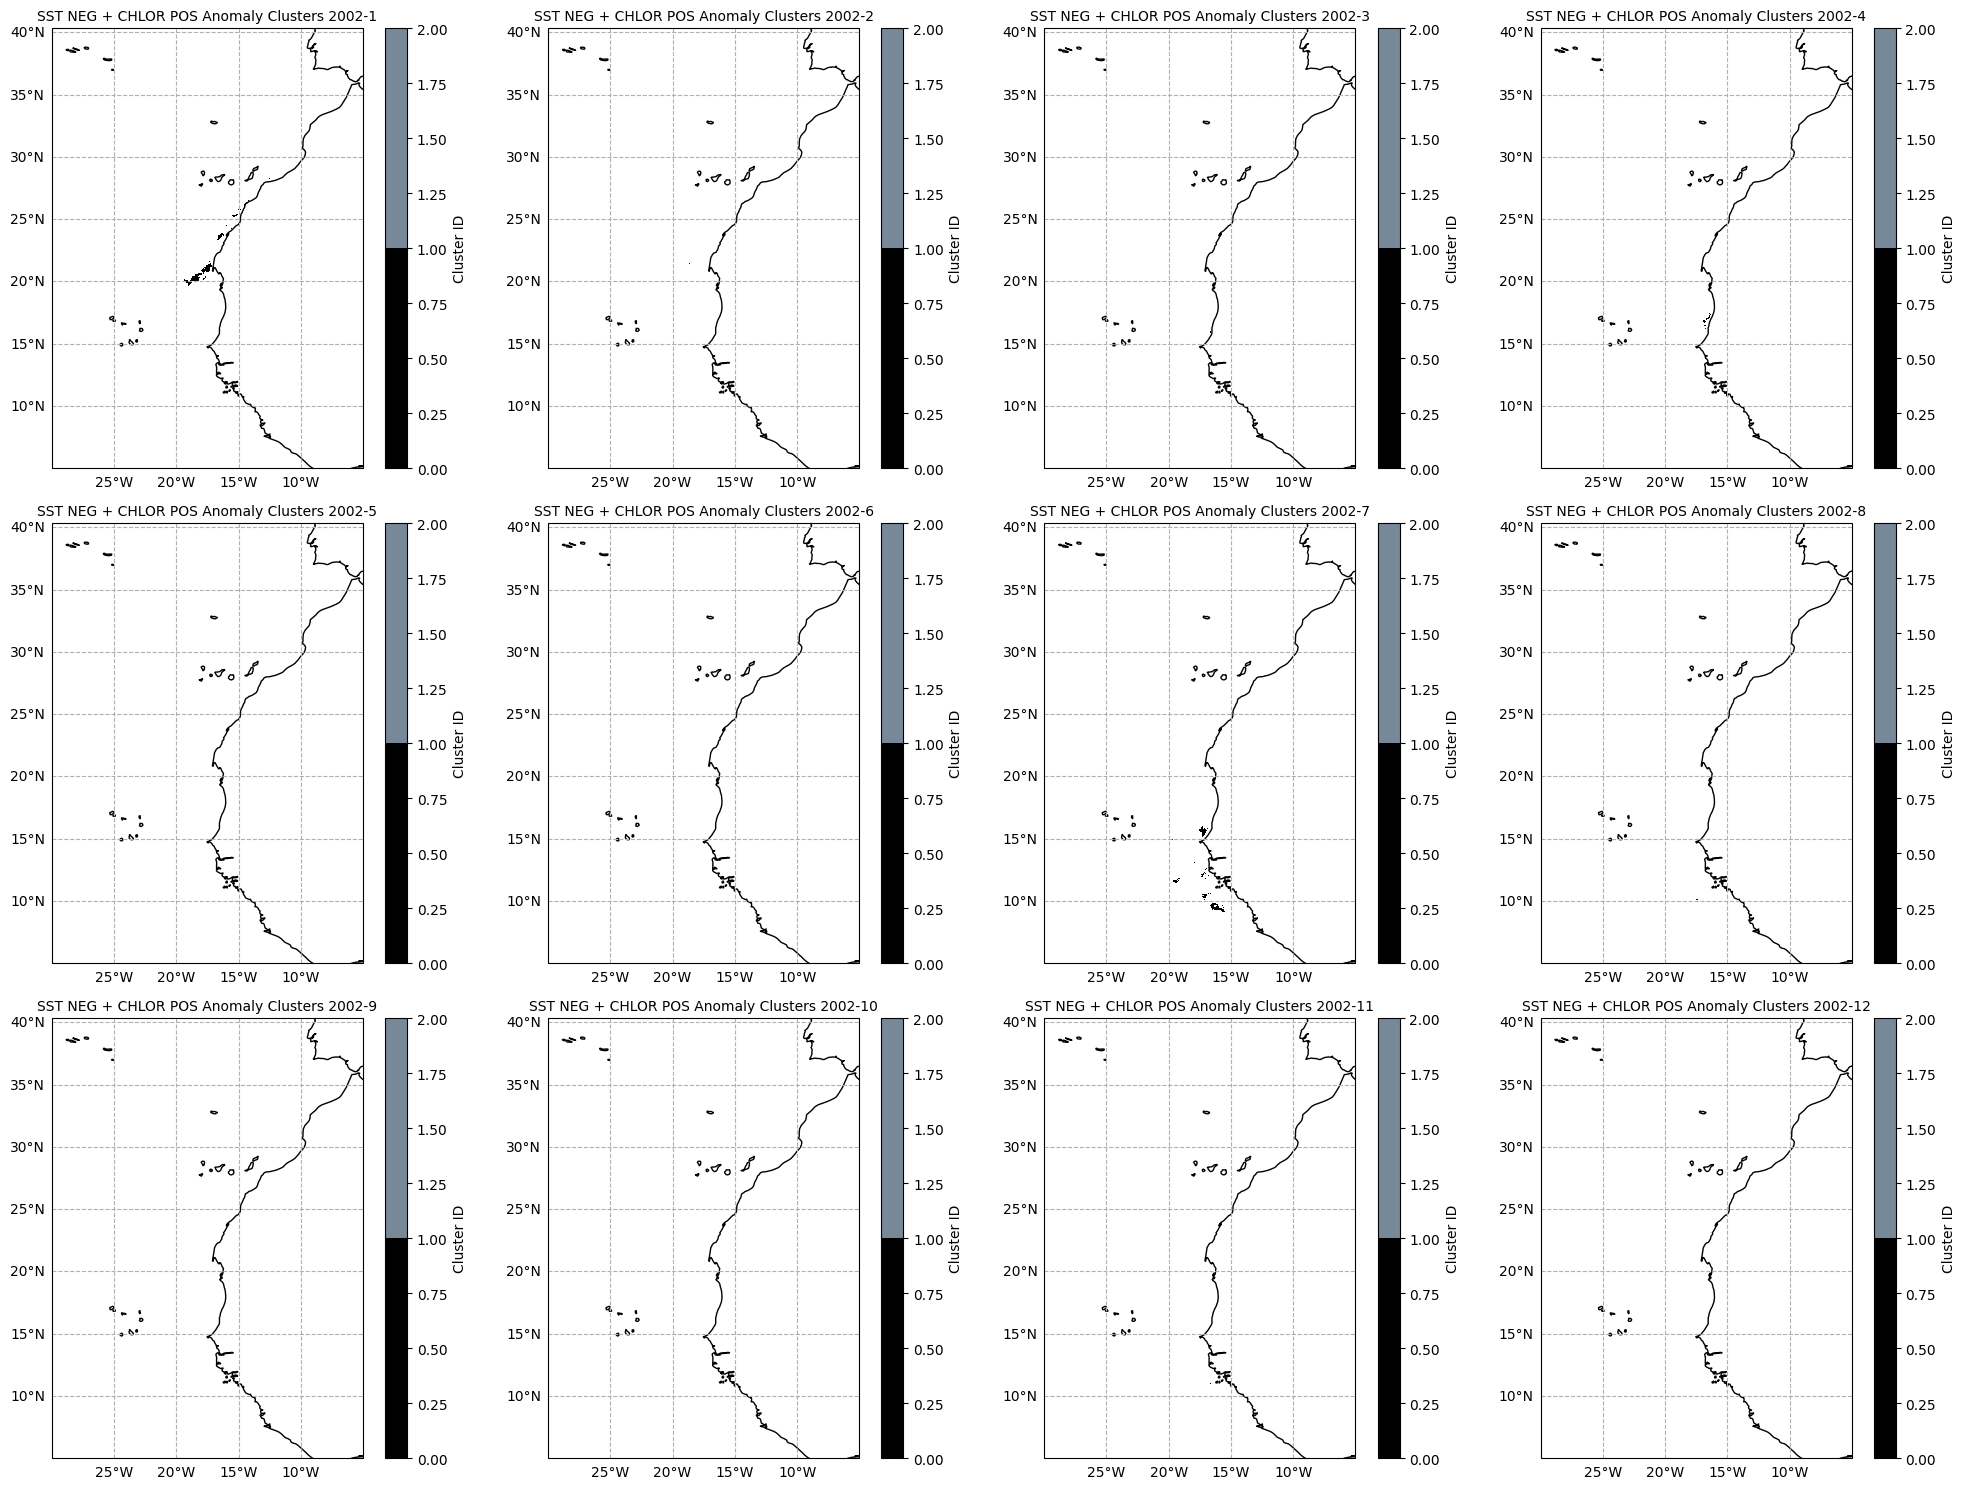

Experiment name: (2) Larger Geo Eps
Found: 11 | Discarded: 0 | Runtime: 505.65 seconds
File name: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_1_50_50_500_1.pkl


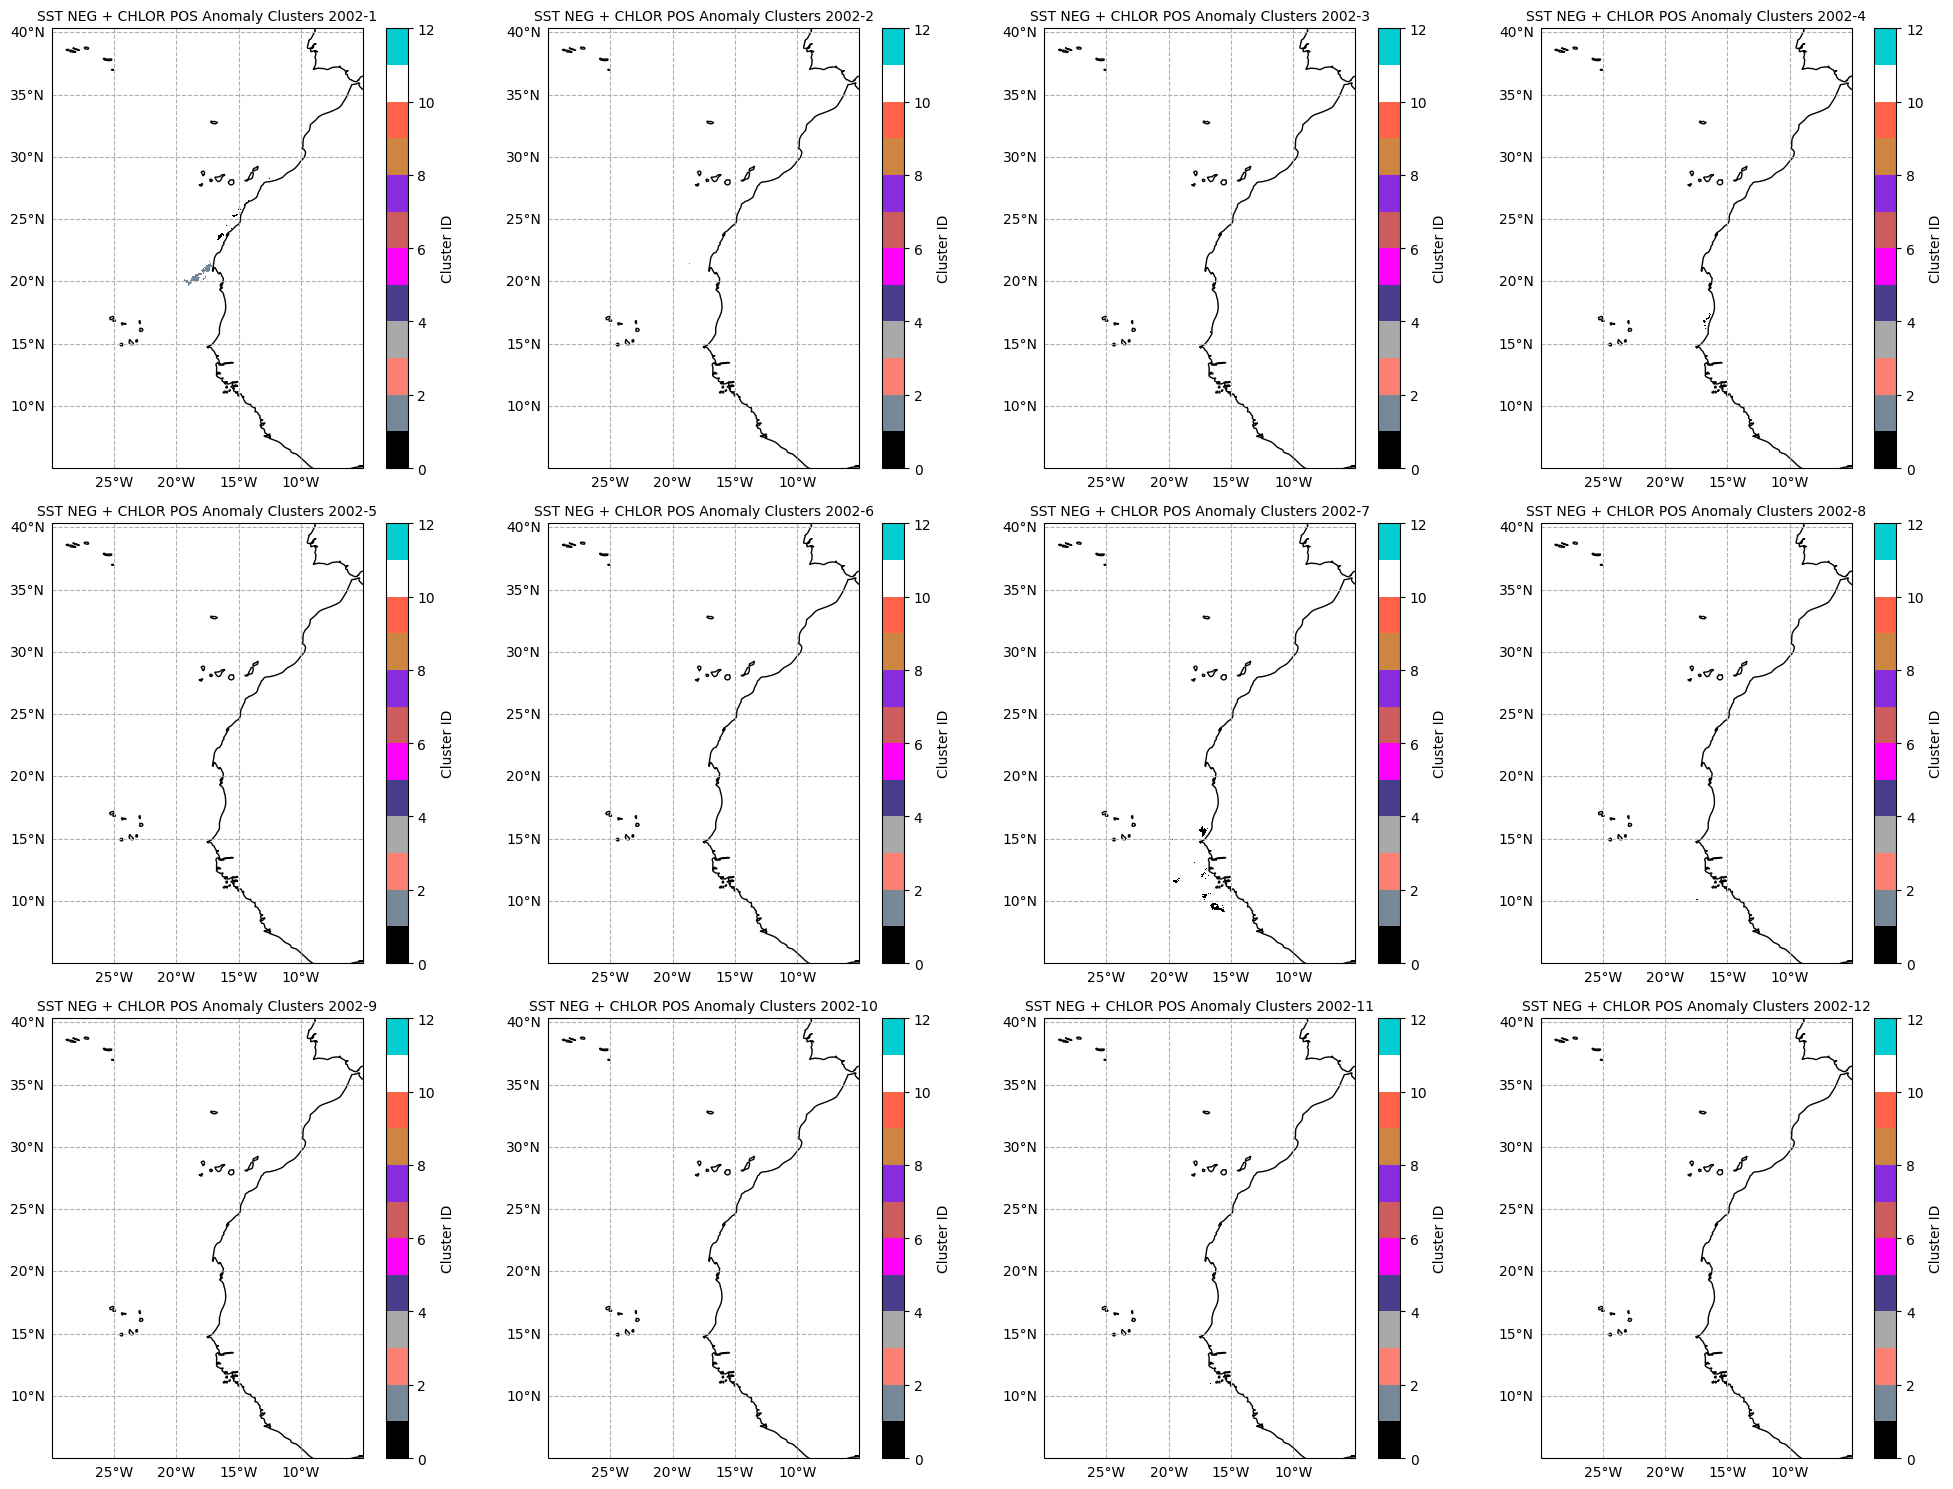

Experiment name: (2) Larger Time Eps
Found: 7 | Discarded: 0 | Runtime: 130.18 seconds
File name: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_2_20_20_500_1.pkl


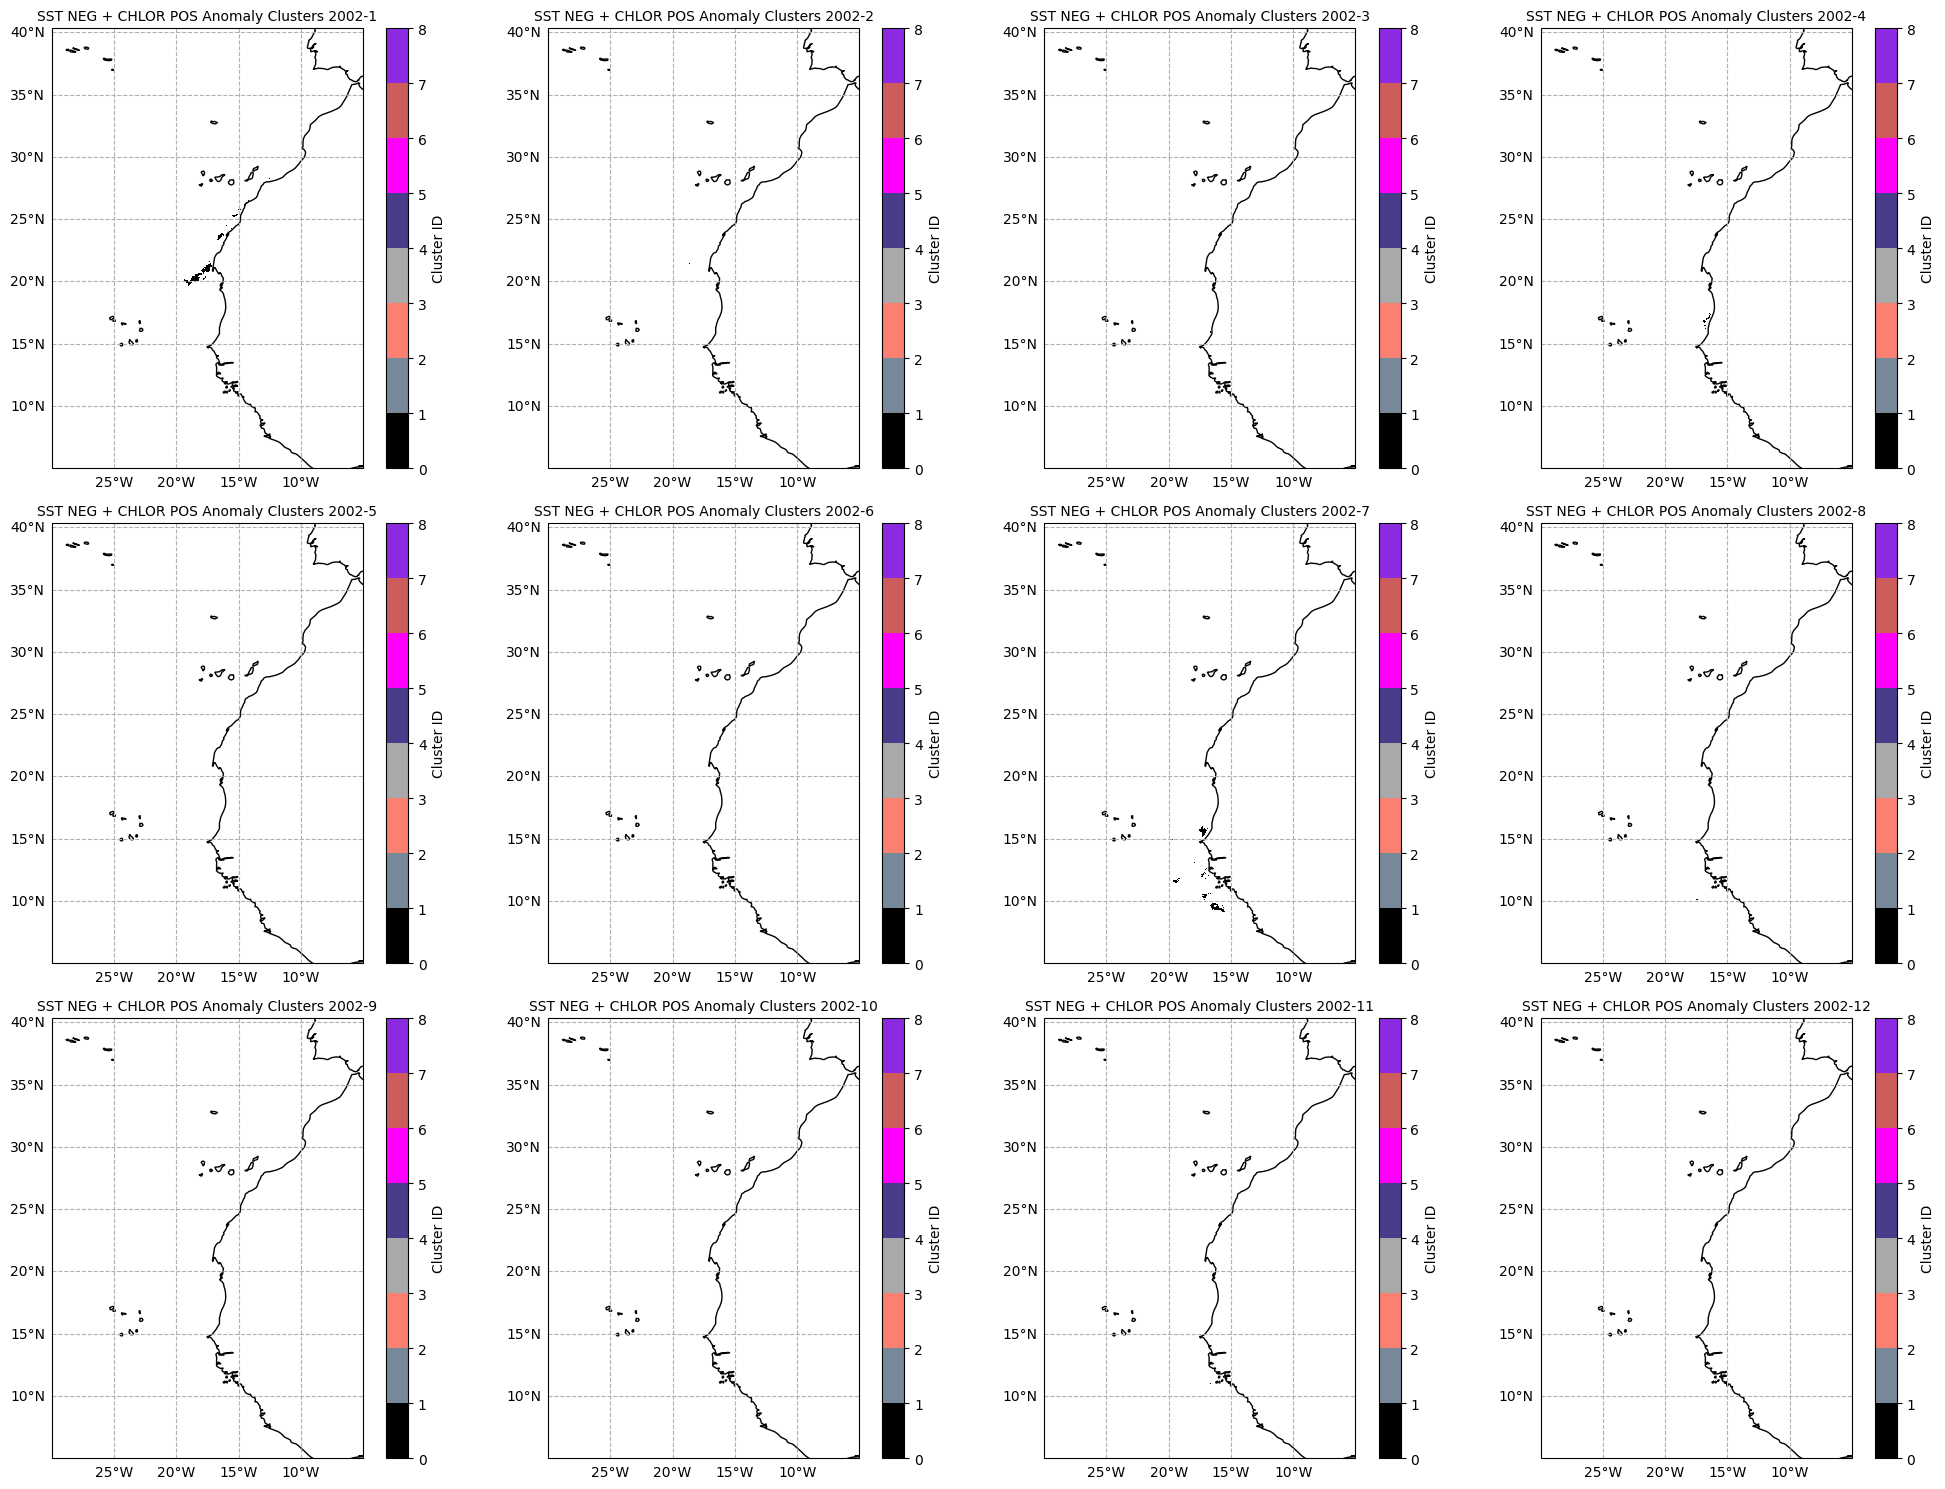

Experiment name: (2) Much Larger Time Eps
Found: 6 | Discarded: 0 | Runtime: 413.11 seconds
File name: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_12_20_20_500_1.pkl


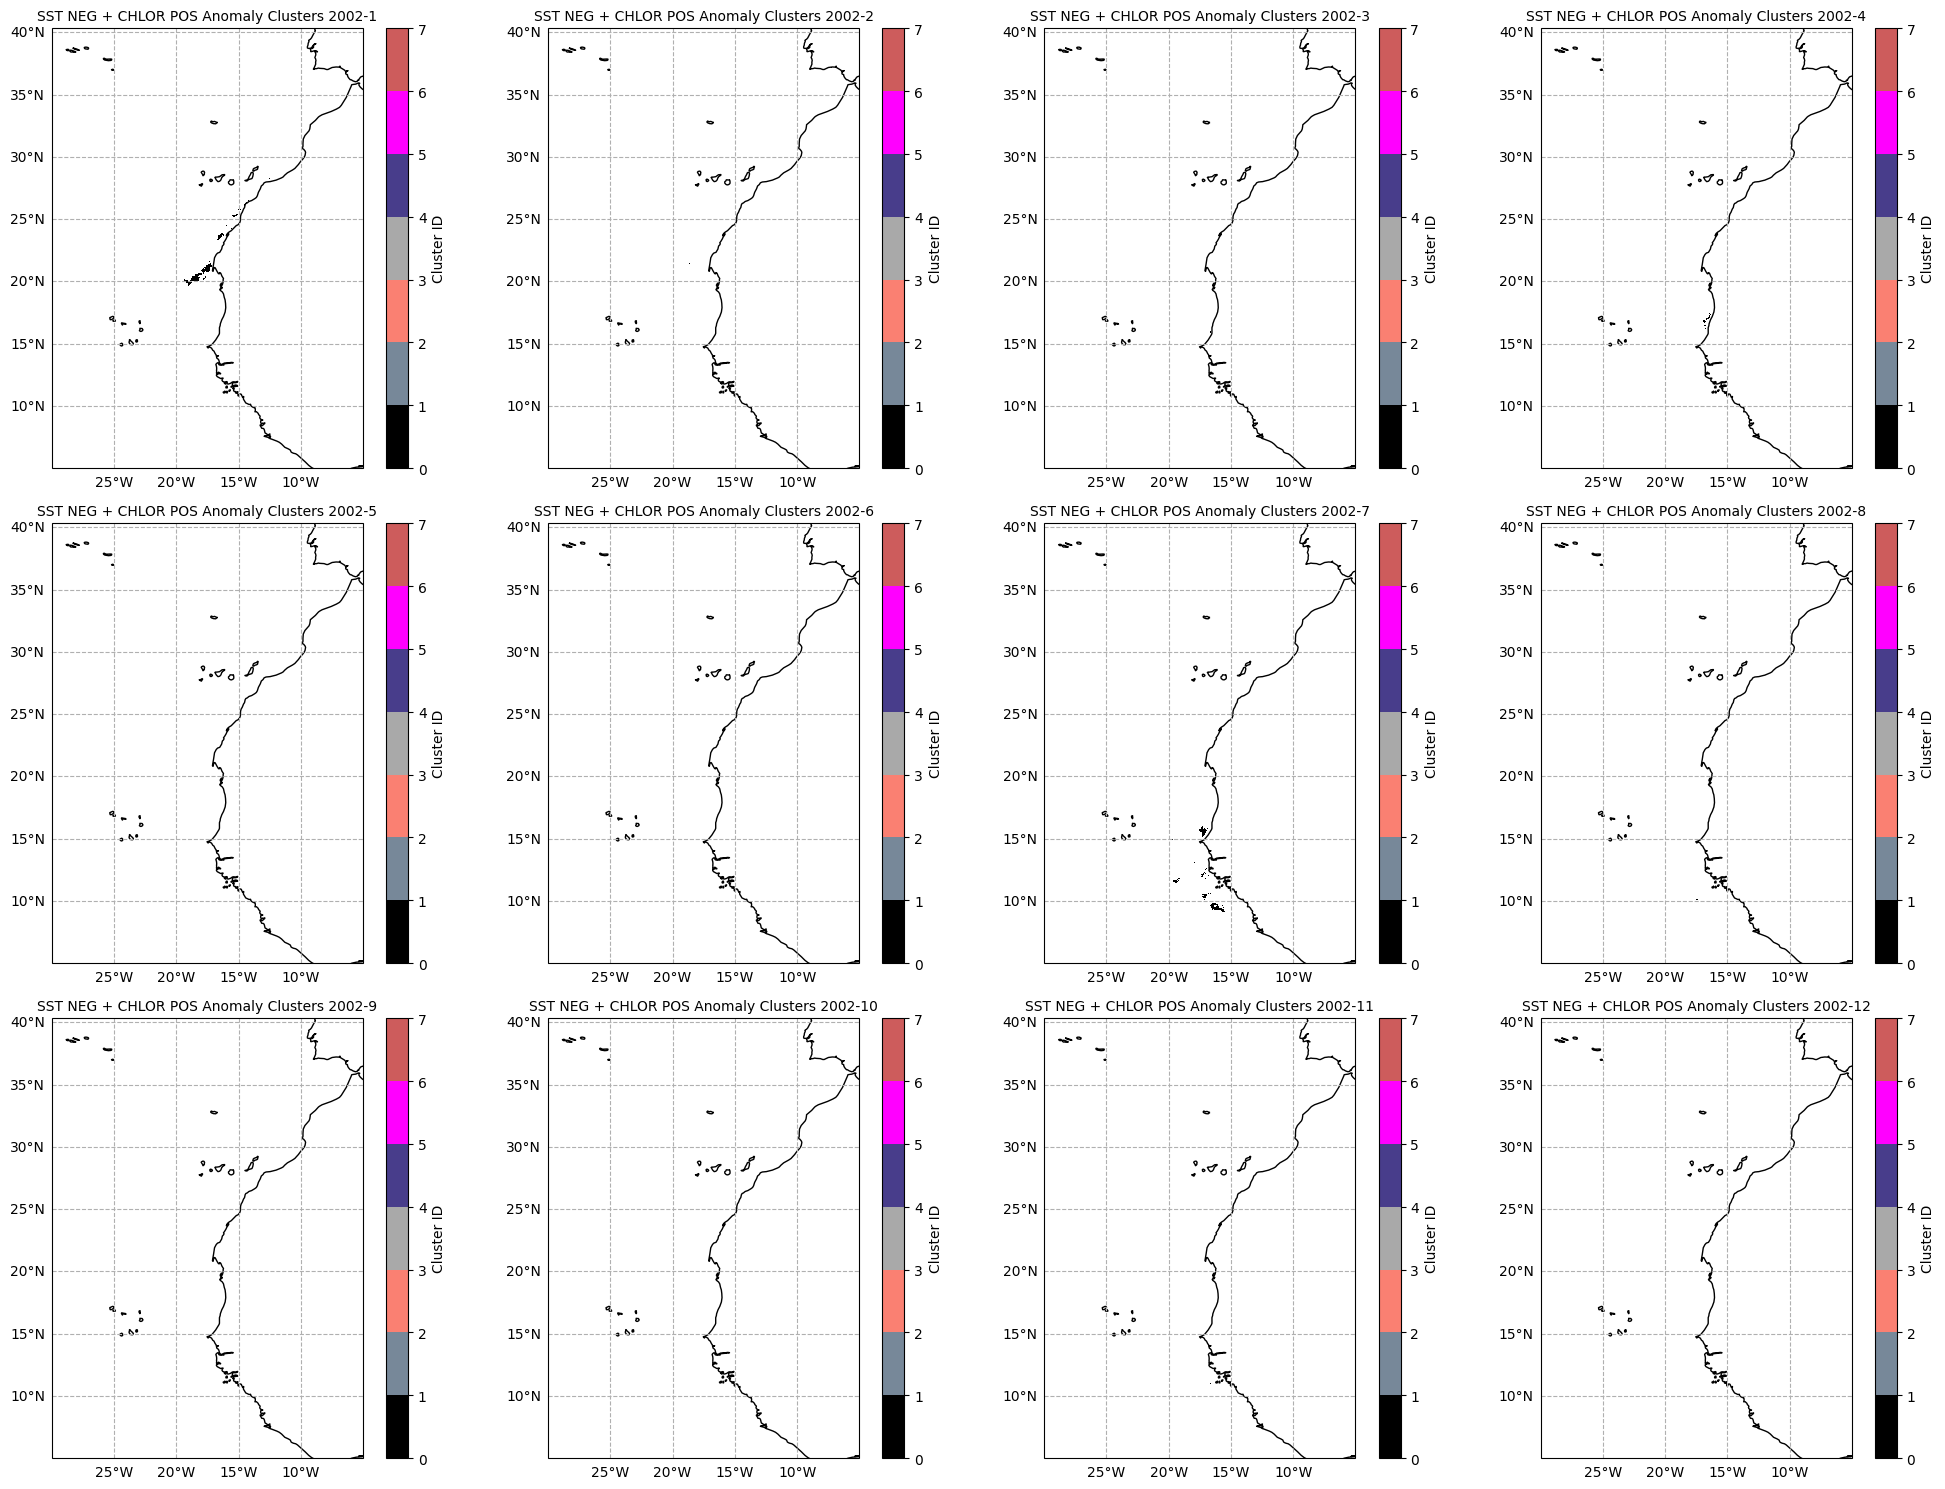

In [7]:
for experiment_result in experiment_results:
    clusters, n_clusters, n_discarded, run_seconds, file_name, experiment_name = experiment_result
    print(f"Experiment name: {experiment_name}")
    print(f"Found: {n_clusters} | Discarded: {n_discarded} | Runtime: {run_seconds:.2f} seconds")
    print(f"File name: {file_name}")
    plot_n_spatial_variable(
        [clusters[i] for i in range(12)],
        clusters.lat,
        clusters.lon,
        nrows = 3,
        ncols = 4,
        i_width = 5,
        i_height = 5,
        clim=[0, n_clusters+1], 
        titles = [f'SST NEG + CHLOR POS Anomaly Clusters {start_date[:4]}-{i+1}' for i in range(12)],
        plot_label = 'Cluster ID',
        cmap = 'labels',
        norm_mode = 'none'
    )